# Smart Waste Classification Using Image Processing
### Dataset: TrashNet
### Classifier: MobileNetV2

---


## 1. Import Libraries

In [1]:
# ============================================================
# Smart Waste Classification Using Image Processing
# Dataset: TrashNet
# Classifier: MobileNetV2
# ============================================================

# -----------------------------
# 1. Import Libraries
# -----------------------------

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import kagglehub
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

from sklearn.metrics import classification_report, confusion_matrix

2026-06-01 01:18:25.677349: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-01 01:18:25.882521: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-01 01:18:26.680412: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-01 01:18:29.495543: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## 2. Download and Load Dataset

In [2]:
path = kagglehub.dataset_download("feyzazkefe/trashnet")
dataset_dir = os.path.join(path, "dataset-resized")

print("Dataset path:", dataset_dir)
print("Classes:", os.listdir(dataset_dir))

Dataset path: /home/norah/.cache/kagglehub/datasets/feyzazkefe/trashnet/versions/1/dataset-resized
Classes: ['glass', 'metal', 'cardboard', 'paper', 'plastic', 'trash']


## 3. Dataset Information

In [3]:
class_counts = {}
total_images = 0
image_sizes = {}

for class_name in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, class_name)

    if os.path.isdir(class_path):
        image_files = os.listdir(class_path)
        class_counts[class_name] = len(image_files)
        total_images += len(image_files)

        for image_name in image_files:
            image_path = os.path.join(class_path, image_name)

            try:
                image = Image.open(image_path)
                size = image.size
                image_sizes[size] = image_sizes.get(size, 0) + 1
            except:
                pass

print("Dataset Information:")
print("Total number of images:", total_images)
print("Number of classes:", len(class_counts))
print("\nImages per class:")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

print("\nNumber of unique image sizes:", len(image_sizes))
print("Image sizes:")

for size, count in image_sizes.items():
    print(f"{size}: {count} images")

Dataset Information:
Total number of images: 2527
Number of classes: 6

Images per class:
glass: 501
metal: 410
cardboard: 403
paper: 594
plastic: 482
trash: 137

Number of unique image sizes: 1
Image sizes:
(512, 384): 2527 images


## 4. Class Distribution Plot

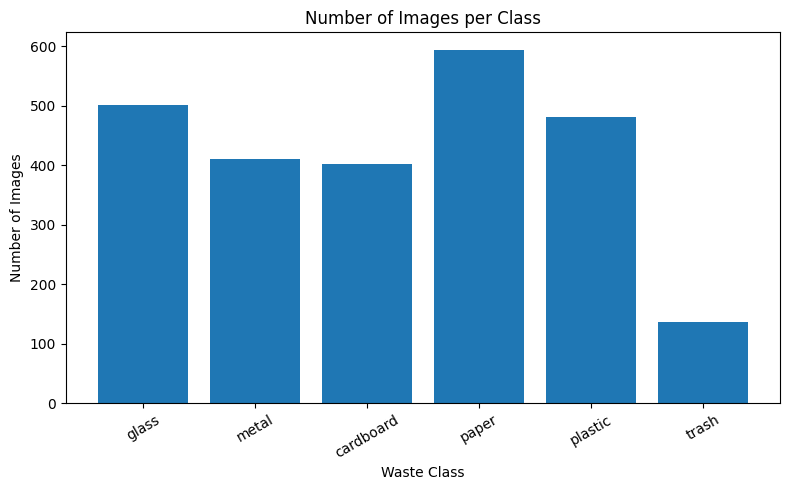

In [4]:
plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Number of Images per Class")
plt.xlabel("Waste Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 5. Visualize Sample Images

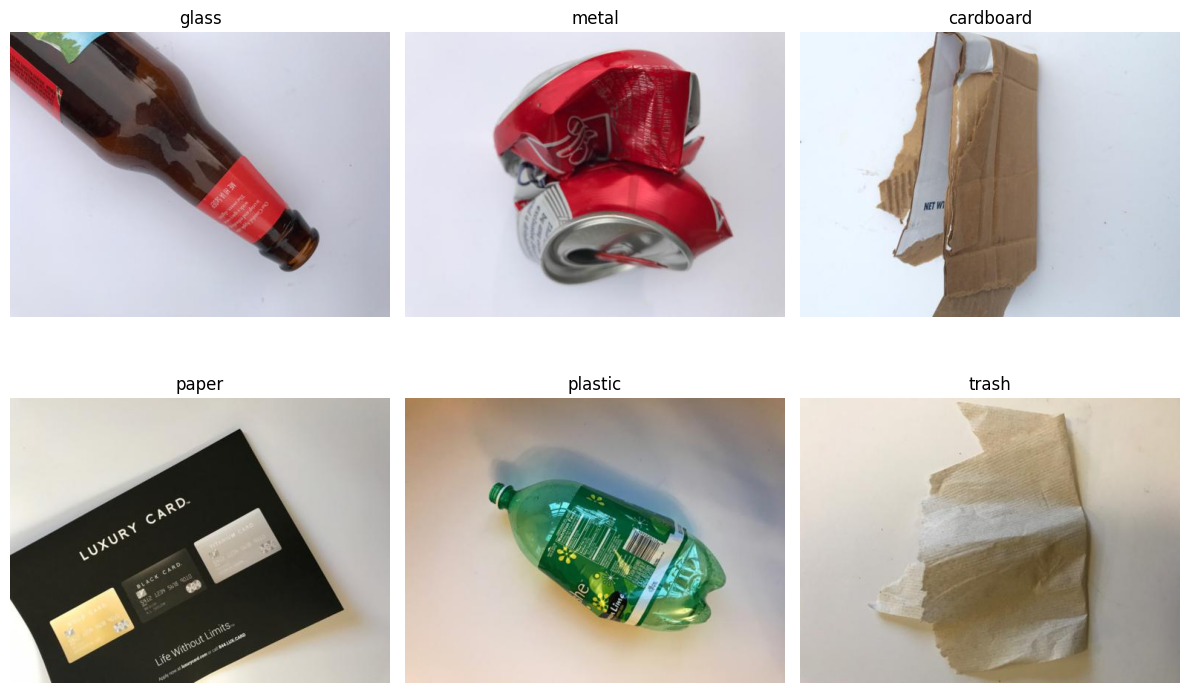

In [5]:
classes = list(class_counts.keys())

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(dataset_dir, class_name)
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Image Processing Functions

In [6]:
def original_preprocess(image):
    """
    Baseline preprocessing:
    Only applies MobileNetV2 preprocessing.
    """
    image = image.astype(np.float32)
    image = preprocess_input(image)
    return image




In [7]:
def median_filter_preprocess(image):
    """
    Applies Median Filter to reduce impulse noise.
    """
    image = image.astype(np.uint8)
    image = cv2.resize(image, (224, 224))
    image = cv2.medianBlur(image, 3)
    image = preprocess_input(image.astype(np.float32))
    return image




In [8]:
def gaussian_filter_preprocess(image):
    """
    Applies Gaussian Filter to smooth minor variations.
    This was the best-performing preprocessing method.
    """
    image = image.astype(np.uint8)
    image = cv2.resize(image, (224, 224))
    image = cv2.GaussianBlur(image, (3, 3), 0)
    image = preprocess_input(image.astype(np.float32))
    return image




In [9]:
def unsharp_preprocess(image):
    """
    Applies Unsharp Masking to enhance edges.
    """
    image = image.astype(np.uint8)
    image = cv2.resize(image, (224, 224))

    blurred = cv2.GaussianBlur(image, (5, 5), 1)
    sharpened = cv2.addWeighted(image, 1.5, blurred, -0.5, 0)

    image = preprocess_input(sharpened.astype(np.float32))
    return image




In [10]:
def highboost_preprocess(image):
    """
    Applies High-Boost Filtering to strongly enhance details.
    """
    image = image.astype(np.uint8)
    image = cv2.resize(image, (224, 224))

    blurred = cv2.GaussianBlur(image, (5, 5), 1)
    highboost = cv2.addWeighted(image, 2.0, blurred, -1.0, 0)

    image = preprocess_input(highboost.astype(np.float32))
    return image




In [11]:
def histogram_equalization_preprocess(image):
    """
    Applies Histogram Equalization on the brightness channel.
    """
    image = image.astype(np.uint8)
    image = cv2.resize(image, (224, 224))

    ycrcb = cv2.cvtColor(image, cv2.COLOR_RGB2YCrCb)
    ycrcb[:, :, 0] = cv2.equalizeHist(ycrcb[:, :, 0])
    enhanced = cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2RGB)

    image = preprocess_input(enhanced.astype(np.float32))
    return image




In [12]:
def gaussian_canny_preprocess(image):
    """
    Applies Gaussian Filter followed by Canny edge enhancement.
    """
    image = image.astype(np.uint8)
    image = cv2.resize(image, (224, 224))

    blurred = cv2.GaussianBlur(image, (3, 3), 0)
    gray = cv2.cvtColor(blurred, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 100, 200)
    edges_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)

    enhanced = cv2.addWeighted(blurred, 0.85, edges_rgb, 0.15, 0)

    image = preprocess_input(enhanced.astype(np.float32))
    return image




In [13]:
def morphology_preprocess(image):
    """
    Applies thresholding, opening, and closing.
    Tested as morphological preprocessing.
    """
    image = image.astype(np.uint8)
    image = cv2.resize(image, (224, 224))

    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    _, binary = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    kernel = np.ones((5, 5), np.uint8)

    opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

    segmented = cv2.bitwise_and(image, image, mask=closed)

    image = preprocess_input(segmented.astype(np.float32))
    return image

## 7. Visualize Preprocessing Techniques

In [14]:
def get_six_sample_images():
    sample_images = []

    for class_name in classes:
        class_path = os.path.join(dataset_dir, class_name)
        image_name = os.listdir(class_path)[0]
        image_path = os.path.join(class_path, image_name)

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (224, 224))

        sample_images.append((class_name, image))

    return sample_images


sample_images = get_six_sample_images()

### Apply Methods for Display

In [15]:
def apply_display_method(image, method_name):
    if method_name == "Original":
        return image

    elif method_name == "Gaussian Filter":
        return cv2.GaussianBlur(image, (3, 3), 0)

    elif method_name == "Median Filter":
        return cv2.medianBlur(image, 3)

    elif method_name == "Unsharp Masking":
        blurred = cv2.GaussianBlur(image, (5, 5), 1)
        return cv2.addWeighted(image, 1.5, blurred, -0.5, 0)

    elif method_name == "High-Boost Filtering":
        blurred = cv2.GaussianBlur(image, (5, 5), 1)
        return cv2.addWeighted(image, 2.0, blurred, -1.0, 0)

    elif method_name == "Histogram Equalization":
        ycrcb = cv2.cvtColor(image, cv2.COLOR_RGB2YCrCb)
        ycrcb[:, :, 0] = cv2.equalizeHist(ycrcb[:, :, 0])
        return cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2RGB)

    elif method_name == "Gaussian + Canny":
        blurred = cv2.GaussianBlur(image, (3, 3), 0)
        gray = cv2.cvtColor(blurred, cv2.COLOR_RGB2GRAY)
        edges = cv2.Canny(gray, 100, 200)
        edges_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
        return cv2.addWeighted(blurred, 0.85, edges_rgb, 0.15, 0)

    return image

### Plot 6 Images for One Method

In [16]:
def show_method_images(method_name):
    plt.figure(figsize=(14, 8))

    for i, (class_name, image) in enumerate(sample_images):
        processed_image = apply_display_method(image, method_name)

        plt.subplot(2, 3, i + 1)
        plt.imshow(processed_image)
        plt.title(f"{method_name}\n{class_name}")
        plt.axis("off")

    plt.suptitle(f"{method_name} Applied to Six Different Classes", fontsize=16)
    plt.tight_layout()
    plt.show()

### Plot Histograms for 6 Images

In [17]:
def show_method_histograms(method_name):
    plt.figure(figsize=(14, 8))

    for i, (class_name, image) in enumerate(sample_images):
        processed_image = apply_display_method(image, method_name)
        gray = cv2.cvtColor(processed_image, cv2.COLOR_RGB2GRAY)

        plt.subplot(2, 3, i + 1)
        plt.hist(gray.ravel(), bins=256, range=(0, 256))
        plt.title(f"{method_name} Histogram\n{class_name}")
        plt.xlabel("Pixel Intensity")
        plt.ylabel("Frequency")

    plt.suptitle(f"Histograms After Applying {method_name}", fontsize=16)
    plt.tight_layout()
    plt.show()

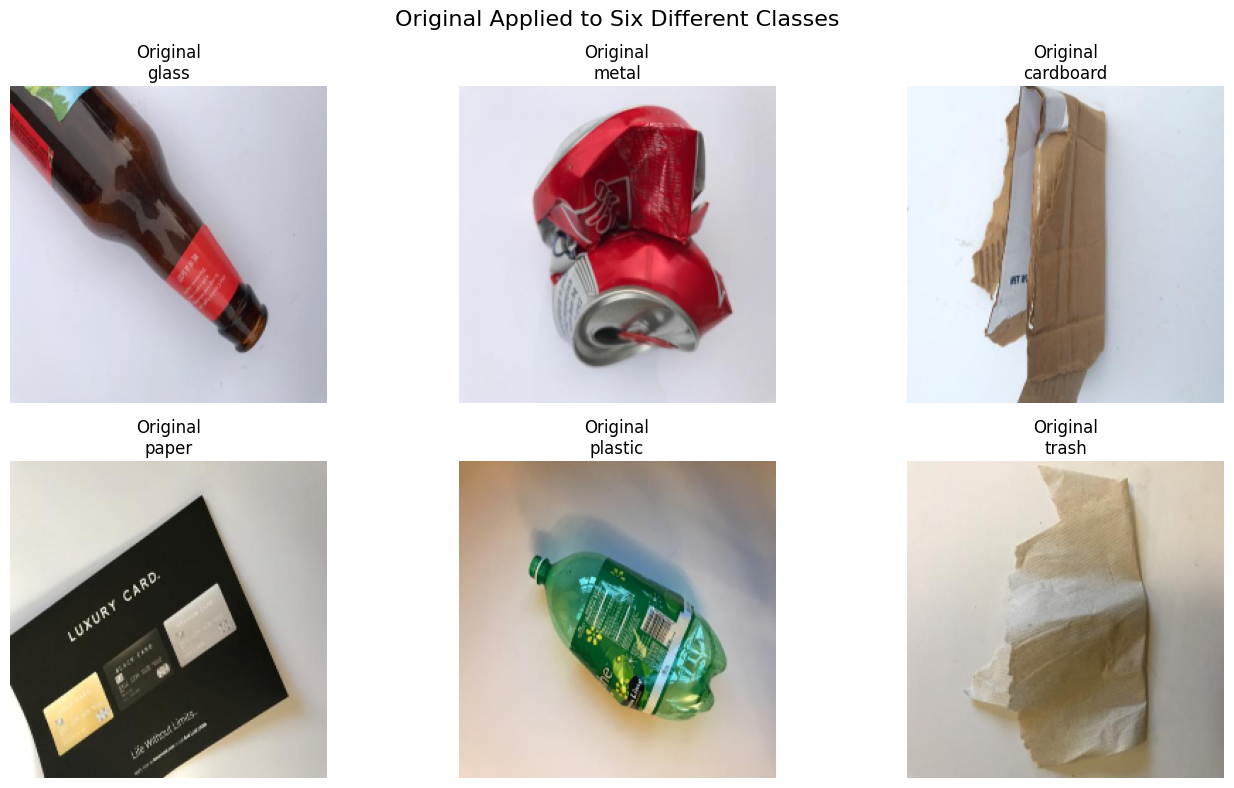

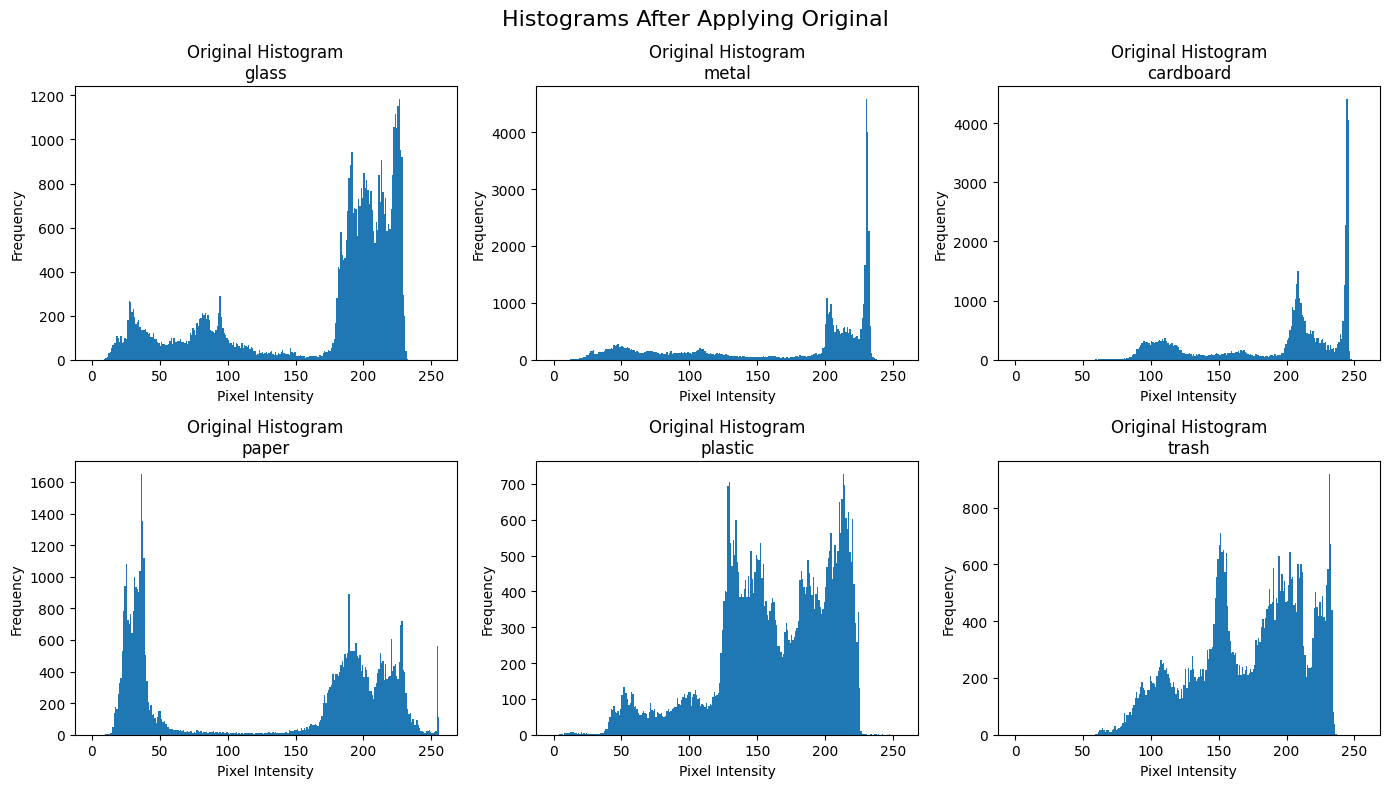

In [18]:
show_method_images("Original")
show_method_histograms("Original")



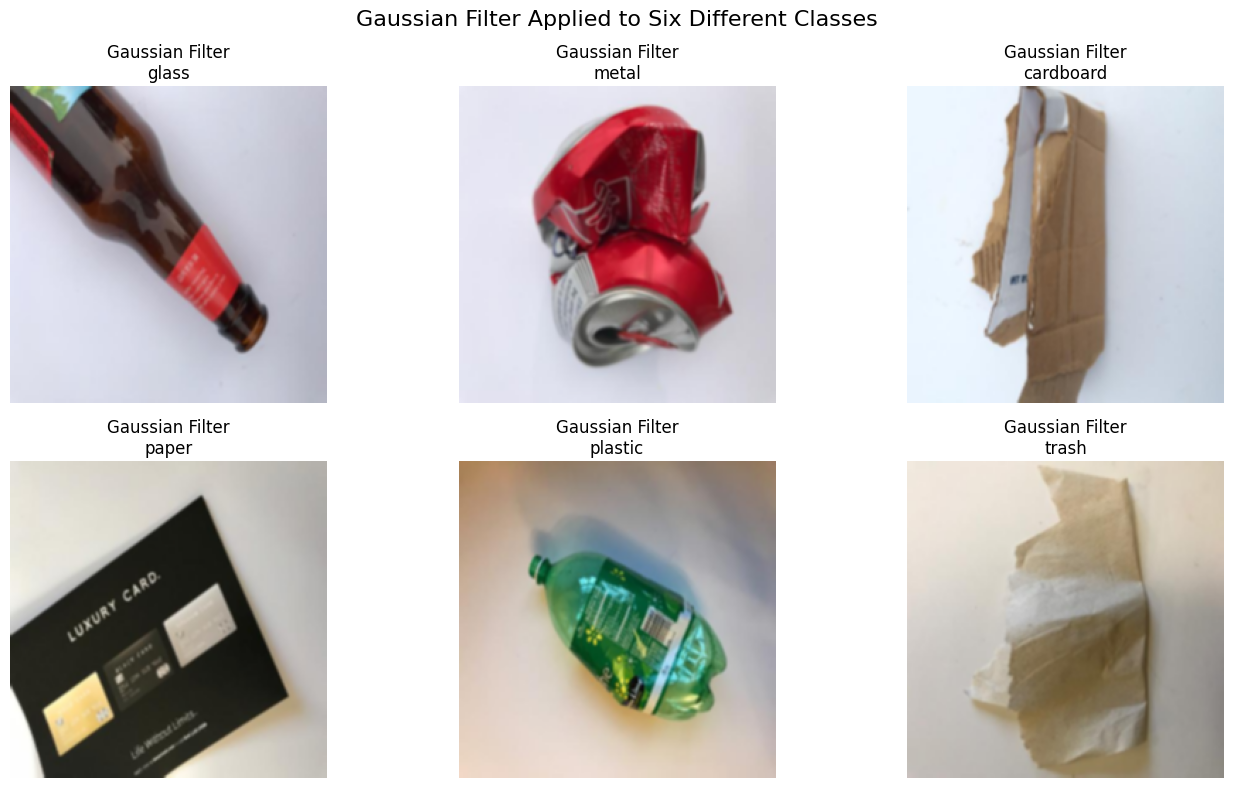

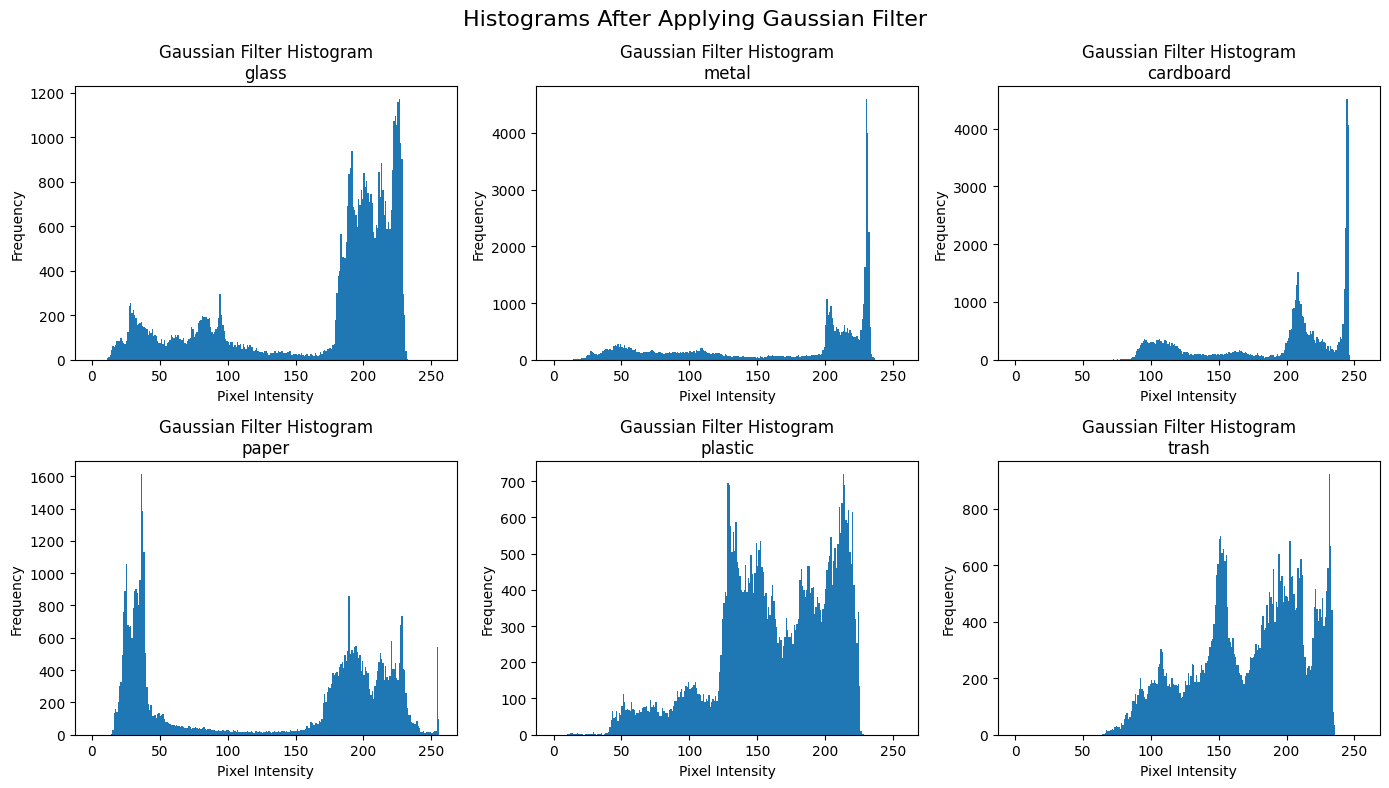

In [19]:
show_method_images("Gaussian Filter")
show_method_histograms("Gaussian Filter")



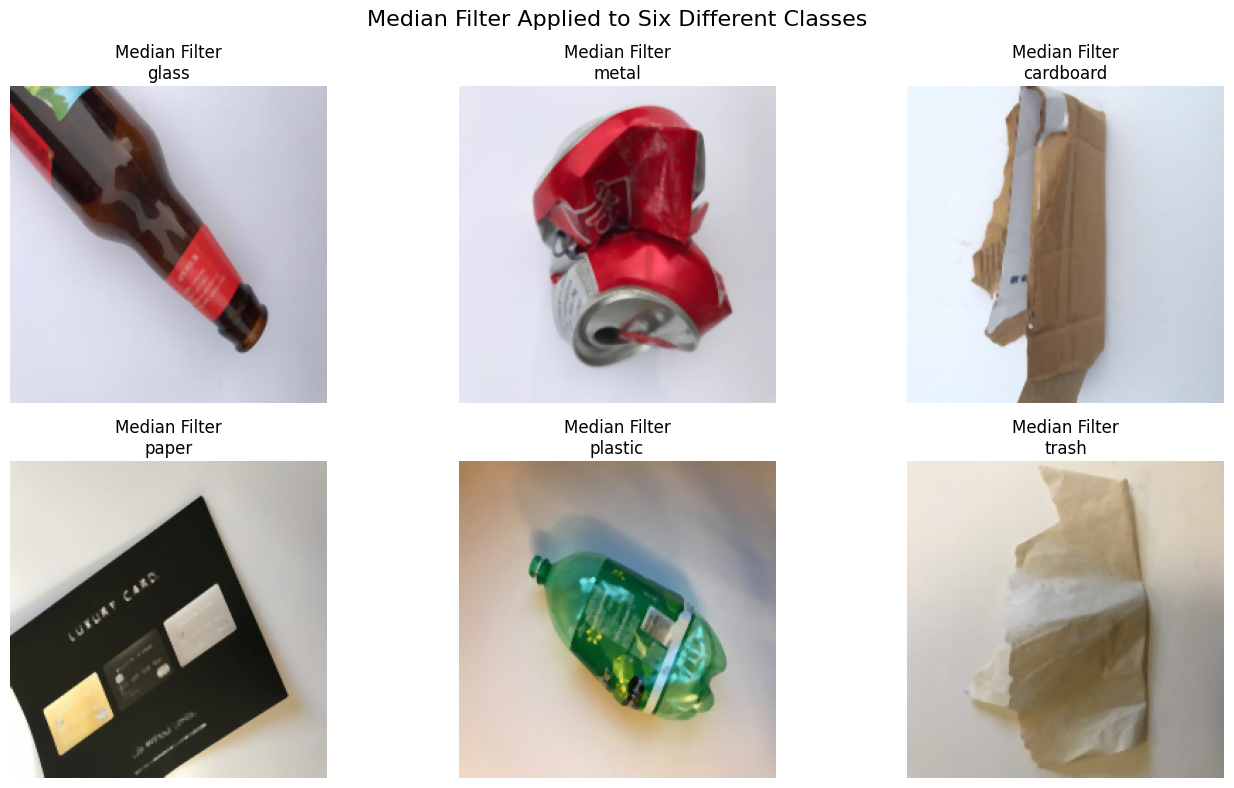

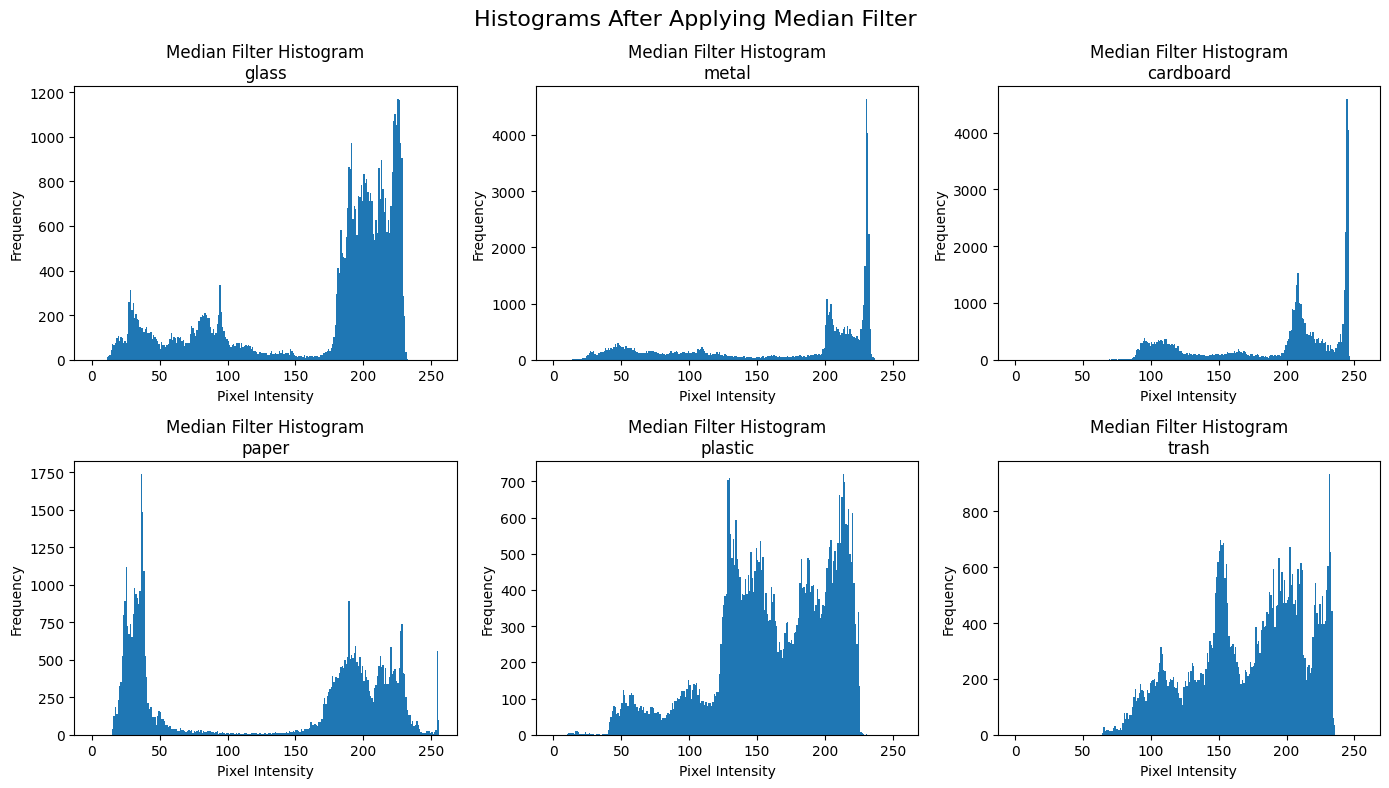

In [20]:
show_method_images("Median Filter")
show_method_histograms("Median Filter")


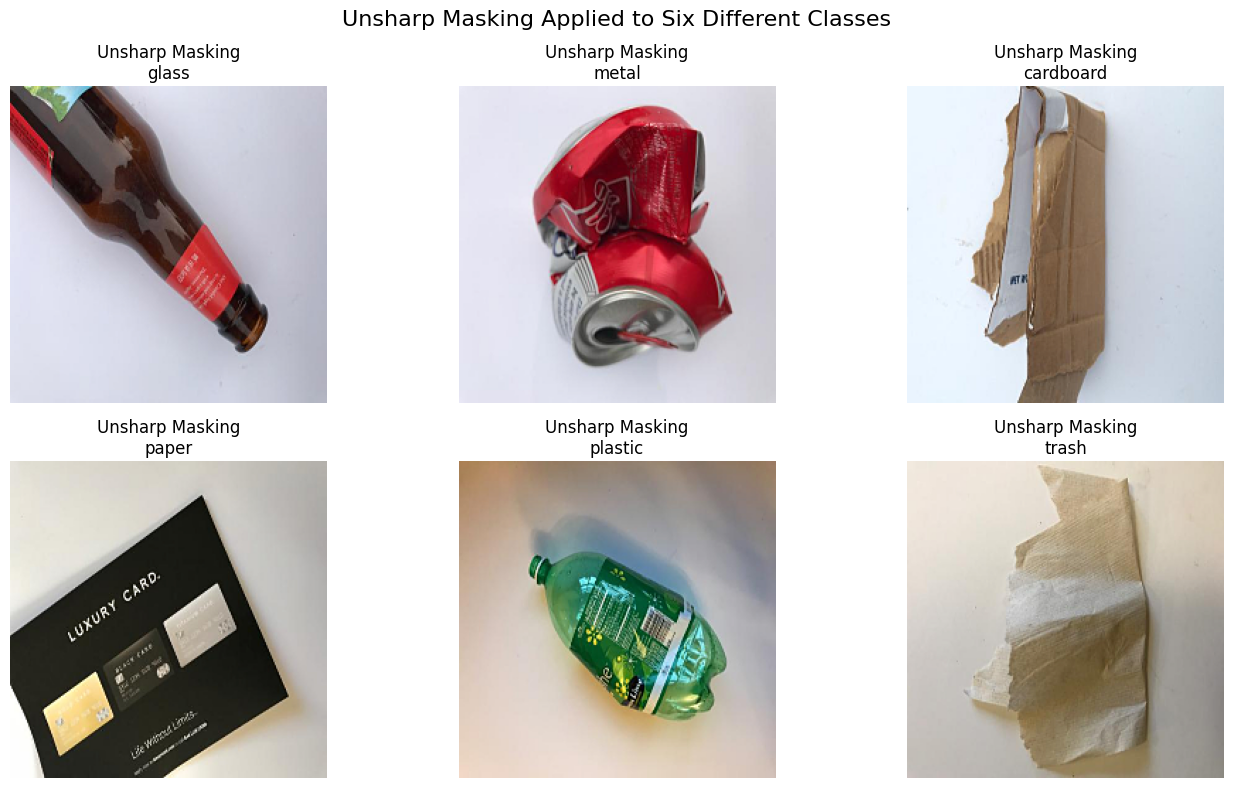

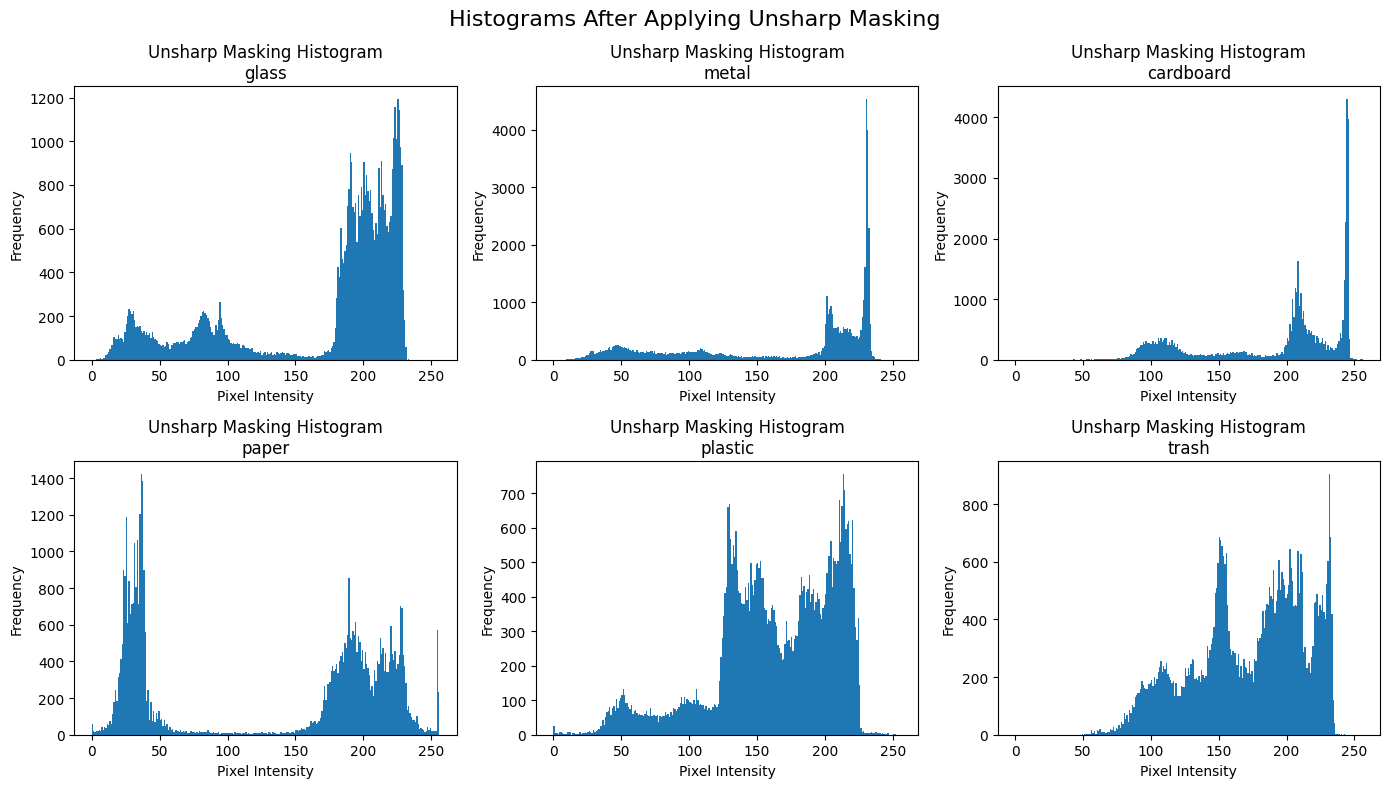

In [21]:
show_method_images("Unsharp Masking")
show_method_histograms("Unsharp Masking")


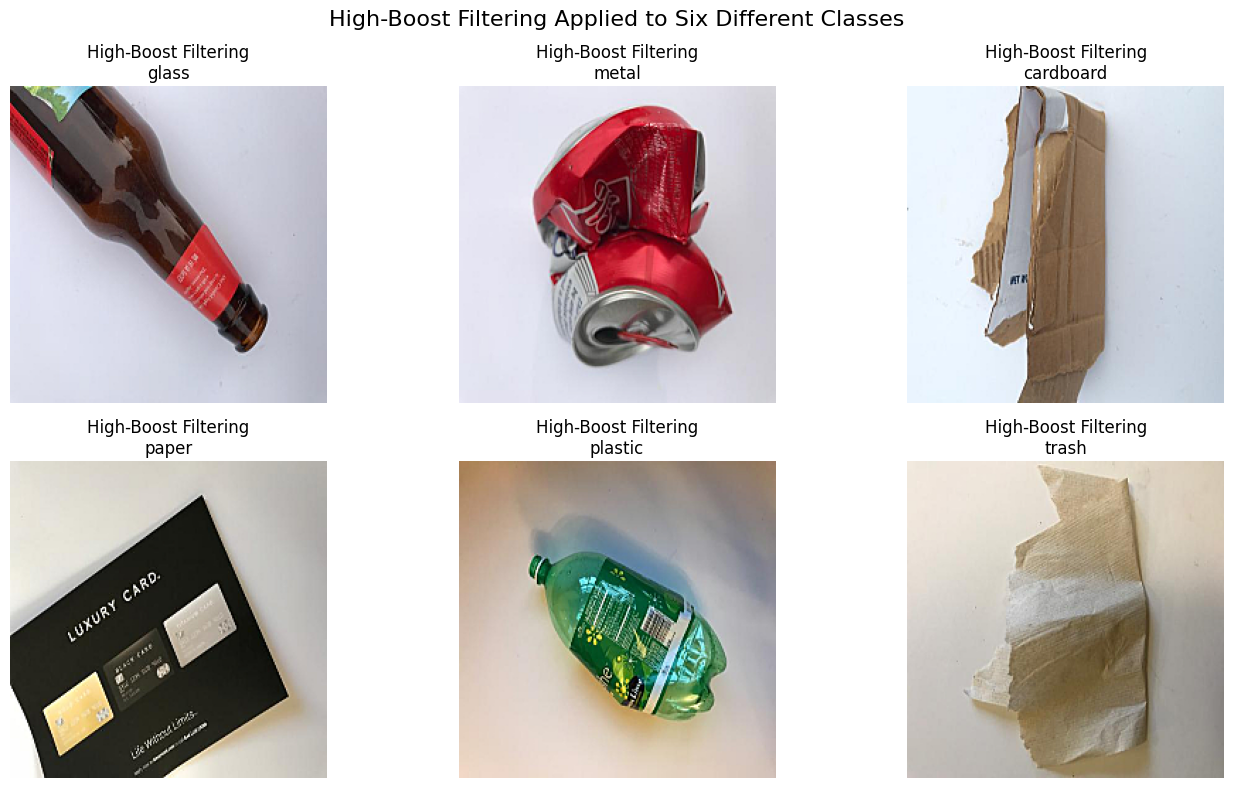

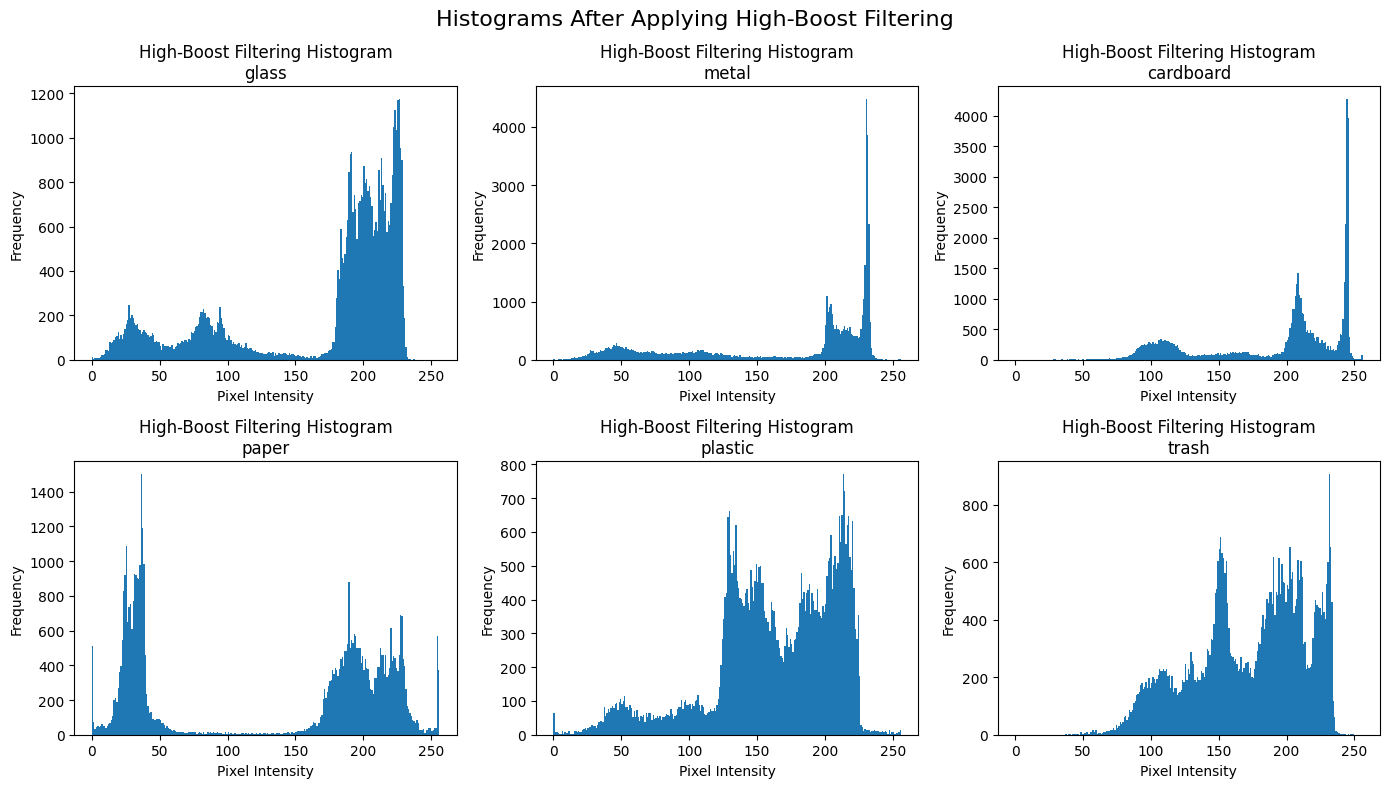

In [22]:

show_method_images("High-Boost Filtering")
show_method_histograms("High-Boost Filtering")


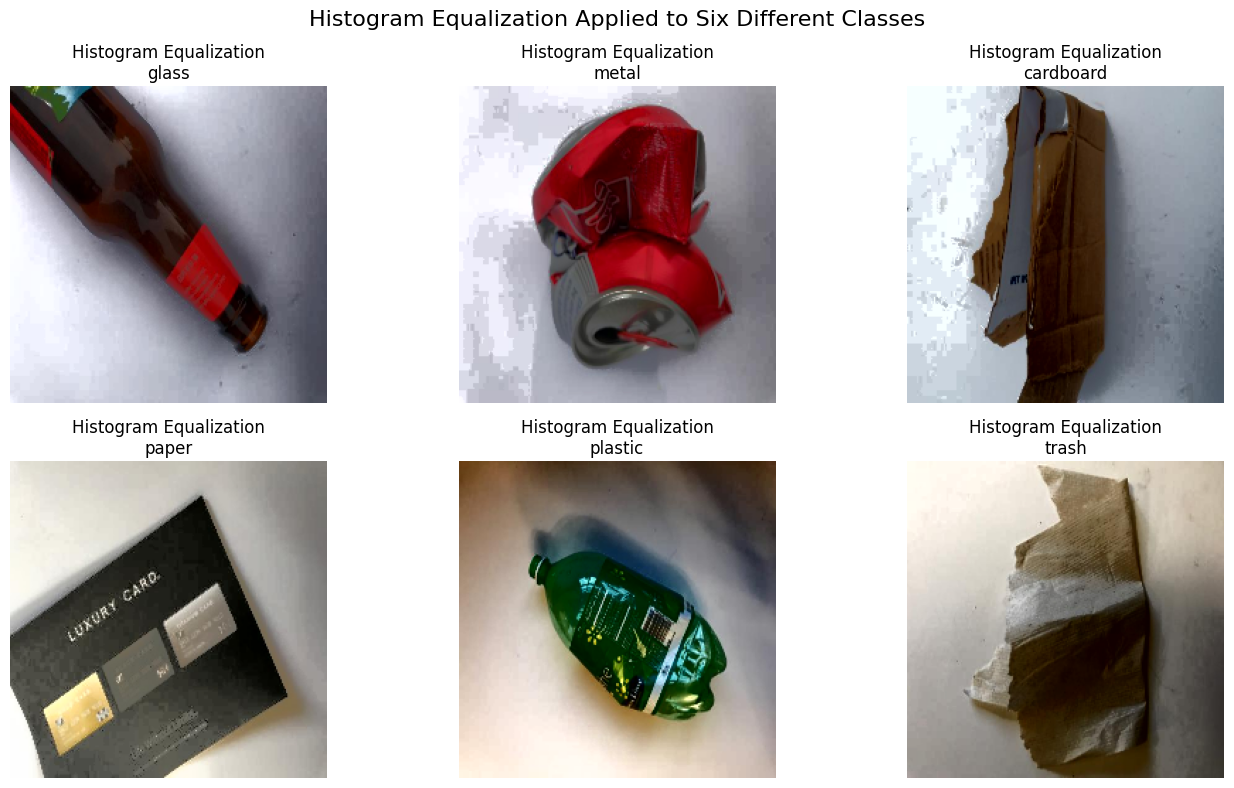

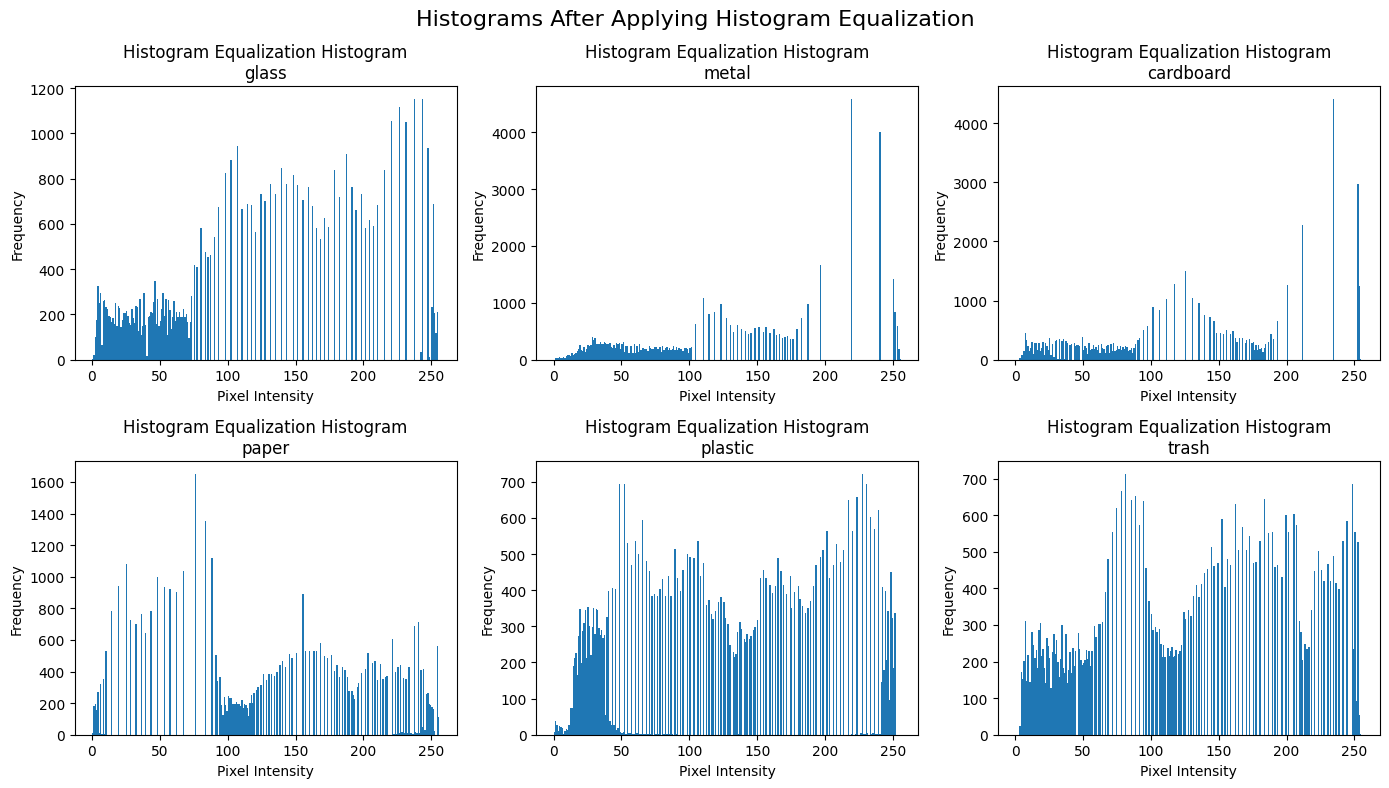

In [23]:

show_method_images("Histogram Equalization")
show_method_histograms("Histogram Equalization")


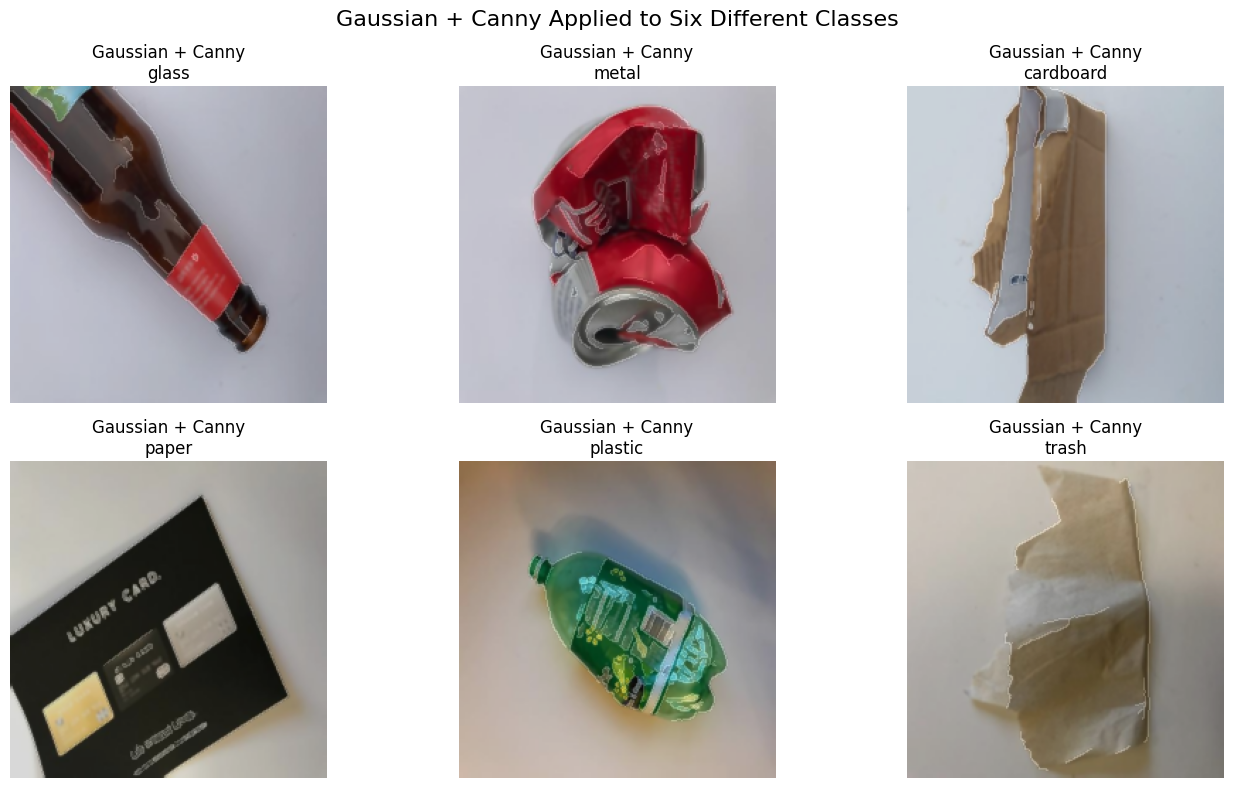

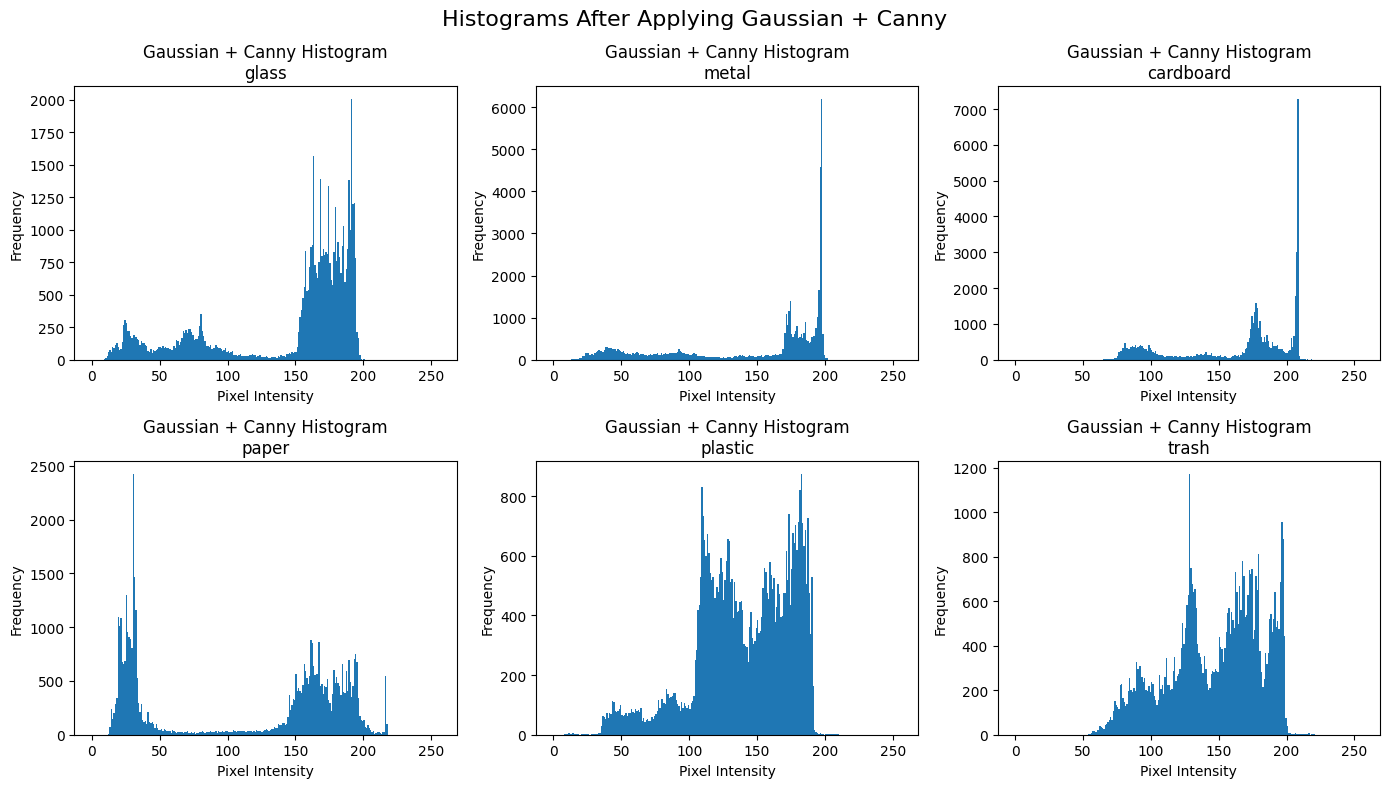

In [24]:

show_method_images("Gaussian + Canny")
show_method_histograms("Gaussian + Canny")



## 8. Create Data Generators

In [27]:
img_size = (224, 224)
batch_size = 32
validation_split = 0.2

def create_generators(preprocess_function):
    datagen = ImageDataGenerator(
        preprocessing_function=preprocess_function,
        validation_split=validation_split
    )

    train_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

    val_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
    
)
    return train_generator, val_generator

## 9. Build MobileNetV2 Model

In [28]:
def build_model():
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dropout(0.3),
        Dense(128, activation="relu"),
        Dense(6, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## 10. Train and Evaluate Function

In [29]:
def train_and_evaluate(method_name, preprocess_function, epochs=10):
    print(f"\n========== Training: {method_name} ==========")

    train_gen, val_gen = create_generators(preprocess_function)

    model = build_model()

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs
    )

    final_accuracy = history.history["val_accuracy"][-1]

    print(f"\n{method_name} Final Validation Accuracy: {final_accuracy:.4f}")

    return {
        "method": method_name,
        "model": model,
        "history": history,
        "val_generator": val_gen,
        "accuracy": final_accuracy
    }

## 11. Run All Experiments

In [30]:
results = []

results.append(train_and_evaluate("Original Images", original_preprocess))



========== Training: Original Images ==========
Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


2026-06-01 01:22:18.995881: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-01 01:22:19.002267: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.6759 - loss: 0.8761 - val_accuracy: 0.7097 - val_loss: 0.7317
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 63s 987ms/step - accuracy: 0.8325 - loss: 0.4683 - val_accuracy: 0.7296 - val_loss: 0.6991
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 861ms/step - accuracy: 0.8775 - loss: 0.3404 - val_accuracy: 0.7416 - val_loss: 0.6900
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 876ms/step - accuracy: 0.9111 - loss: 0.2559 - val_accuracy: 0.7614 - val_loss: 0.6612
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 902ms/step - accuracy: 0.9130 - loss: 0.2268 - val_accuracy: 0.7575 - val_loss: 0.6781
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 875ms/step - accuracy: 0.9387 - loss: 0.1790 - val_accuracy: 0.7614 - val_loss: 0.7138
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 939ms/step - accuracy: 0.9476 - loss: 0.1468 - val_accuracy: 0.7694 - val_loss: 0.6834
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 912ms/step - accuracy: 0.9615 - loss: 0.1258 - val_accurac

In [33]:
results.append(train_and_evaluate("Median Filter", median_filter_preprocess))



========== Training: Median Filter ==========
Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 68s 945ms/step - accuracy: 0.6709 - loss: 0.9110 - val_accuracy: 0.7416 - val_loss: 0.6832
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 907ms/step - accuracy: 0.8202 - loss: 0.4930 - val_accuracy: 0.7396 - val_loss: 0.6519
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 61s 955ms/step - accuracy: 0.8671 - loss: 0.3747 - val_accuracy: 0.7416 - val_loss: 0.7883
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 898ms/step - accuracy: 0.8864 - loss: 0.3046 - val_accuracy: 0.7694 - val_loss: 0.6701
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 939ms/step - accuracy: 0.9056 - loss: 0.2647 - val_accuracy: 0.7535 - val_loss: 0.6850
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 59s 914ms/step - accuracy: 0.9244 - loss: 0.2078 - val_accuracy: 0.7634 - val_loss: 0.7335
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.9323 - loss: 0.1836 - val_accura

In [35]:
results.append(train_and_evaluate("Gaussian Filter", gaussian_filter_preprocess))



========== Training: Gaussian Filter ==========
Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 69s 968ms/step - accuracy: 0.6709 - loss: 0.8761 - val_accuracy: 0.6720 - val_loss: 0.8276
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 59s 920ms/step - accuracy: 0.8211 - loss: 0.4920 - val_accuracy: 0.7197 - val_loss: 0.7166
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 907ms/step - accuracy: 0.8631 - loss: 0.3551 - val_accuracy: 0.7336 - val_loss: 0.6894
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 911ms/step - accuracy: 0.8958 - loss: 0.2869 - val_accuracy: 0.7455 - val_loss: 0.7385
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 906ms/step - accuracy: 0.9076 - loss: 0.2580 - val_accuracy: 0.7654 - val_loss: 0.7738
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 936ms/step - accuracy: 0.9333 - loss: 0.1901 - val_accuracy: 0.7475 - val_loss: 0.7780
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 61s 963ms/step - accuracy: 0.9417 - loss: 0.1661 - val_a

In [36]:
results.append(train_and_evaluate("Unsharp Masking", unsharp_preprocess))



========== Training: Unsharp Masking ==========
Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 70s 972ms/step - accuracy: 0.6961 - loss: 0.8375 - val_accuracy: 0.7396 - val_loss: 0.7374
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 897ms/step - accuracy: 0.8439 - loss: 0.4372 - val_accuracy: 0.7614 - val_loss: 0.6451
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 907ms/step - accuracy: 0.8864 - loss: 0.3292 - val_accuracy: 0.7356 - val_loss: 0.7388
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 885ms/step - accuracy: 0.8943 - loss: 0.2874 - val_accuracy: 0.7475 - val_loss: 0.6834
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 888ms/step - accuracy: 0.9096 - loss: 0.2307 - val_accuracy: 0.7555 - val_loss: 0.7144
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 890ms/step - accuracy: 0.9284 - loss: 0.1959 - val_accuracy: 0.7734 - val_loss: 0.6690
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 914ms/step - accuracy: 0.9501 - loss: 0.1493 - val_a

In [37]:
results.append(train_and_evaluate("High-Boost Filtering", highboost_preprocess))



========== Training: High-Boost Filtering ==========
Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 70s 964ms/step - accuracy: 0.6779 - loss: 0.8800 - val_accuracy: 0.7356 - val_loss: 0.7282
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 946ms/step - accuracy: 0.8360 - loss: 0.4507 - val_accuracy: 0.7475 - val_loss: 0.6656
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 950ms/step - accuracy: 0.8622 - loss: 0.3597 - val_accuracy: 0.7435 - val_loss: 0.6873
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 875ms/step - accuracy: 0.8849 - loss: 0.2968 - val_accuracy: 0.7435 - val_loss: 0.7595
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 875ms/step - accuracy: 0.9061 - loss: 0.2566 - val_accuracy: 0.7515 - val_loss: 0.7126
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 873ms/step - accuracy: 0.9382 - loss: 0.1842 - val_accuracy: 0.7416 - val_loss: 0.6863
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 885ms/step - accuracy: 0.9550 - loss: 0.1385 - 

In [38]:
results.append(train_and_evaluate("Histogram Equalization", histogram_equalization_preprocess))



========== Training: Histogram Equalization ==========
Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 68s 955ms/step - accuracy: 0.6220 - loss: 1.0059 - val_accuracy: 0.6819 - val_loss: 0.8456
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 896ms/step - accuracy: 0.7984 - loss: 0.5471 - val_accuracy: 0.7058 - val_loss: 0.7809
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 868ms/step - accuracy: 0.8414 - loss: 0.4512 - val_accuracy: 0.6740 - val_loss: 0.8939
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 874ms/step - accuracy: 0.8686 - loss: 0.3580 - val_accuracy: 0.7376 - val_loss: 0.8047
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 879ms/step - accuracy: 0.8864 - loss: 0.3059 - val_accuracy: 0.7475 - val_loss: 0.7978
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 867ms/step - accuracy: 0.9027 - loss: 0.2709 - val_accuracy: 0.7555 - val_loss: 0.7655
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 878ms/step - accuracy: 0.9274 - loss: 0.2104 

In [39]:
results.append(train_and_evaluate("Gaussian + Canny", gaussian_canny_preprocess))



========== Training: Gaussian + Canny ==========
Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 70s 963ms/step - accuracy: 0.6403 - loss: 0.9610 - val_accuracy: 0.6938 - val_loss: 0.8052
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 933ms/step - accuracy: 0.7974 - loss: 0.5595 - val_accuracy: 0.7097 - val_loss: 0.7501
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 943ms/step - accuracy: 0.8478 - loss: 0.4154 - val_accuracy: 0.6998 - val_loss: 0.8672
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 936ms/step - accuracy: 0.8740 - loss: 0.3515 - val_accuracy: 0.7495 - val_loss: 0.7497
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 59s 925ms/step - accuracy: 0.8972 - loss: 0.3013 - val_accuracy: 0.7455 - val_loss: 0.7652
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 931ms/step - accuracy: 0.9076 - loss: 0.2571 - val_accuracy: 0.7594 - val_loss: 0.7431
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 63s 987ms/step - accuracy: 0.9293 - loss: 0.2127 - val_

In [40]:
results.append(train_and_evaluate("Morphological Processing", morphology_preprocess))


========== Training: Morphological Processing ==========
Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 69s 923ms/step - accuracy: 0.5474 - loss: 1.2229 - val_accuracy: 0.5984 - val_loss: 1.0495
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 59s 925ms/step - accuracy: 0.7223 - loss: 0.7779 - val_accuracy: 0.6262 - val_loss: 1.0035
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 913ms/step - accuracy: 0.7554 - loss: 0.6644 - val_accuracy: 0.6561 - val_loss: 0.9657
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 897ms/step - accuracy: 0.8019 - loss: 0.5490 - val_accuracy: 0.6461 - val_loss: 0.9618
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 887ms/step - accuracy: 0.8093 - loss: 0.5241 - val_accuracy: 0.6640 - val_loss: 0.9224
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 61s 950ms/step - accuracy: 0.8458 - loss: 0.4372 - val_accuracy: 0.6163 - val_loss: 1.0826
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 934ms/step - accuracy: 0.8478 - loss: 0.405

## 12. Print Accuracy Comparison Table

In [41]:
print("\n========== Final Accuracy Comparison ==========")

baseline_accuracy = results[0]["accuracy"]

for result in results:
    improvement = result["accuracy"] - baseline_accuracy
    print(
        f"{result['method']:<30} "
        f"Accuracy: {result['accuracy']:.4f} "
        f"Improvement: {improvement:+.4f}"
    )

best_result = max(results, key=lambda x: x["accuracy"])

print("\nBest Method:", best_result["method"])
print("Best Validation Accuracy:", round(best_result["accuracy"], 4))


========== Final Accuracy Comparison ==========
Original Images                Accuracy: 0.7555 Improvement: +0.0000
Median Filter                  Accuracy: 0.7773 Improvement: +0.0219
Gaussian Filter                Accuracy: 0.7753 Improvement: +0.0199
Gaussian Filter                Accuracy: 0.7873 Improvement: +0.0318
Unsharp Masking                Accuracy: 0.7654 Improvement: +0.0099
High-Boost Filtering           Accuracy: 0.7793 Improvement: +0.0239
Histogram Equalization         Accuracy: 0.7217 Improvement: -0.0338
Gaussian + Canny               Accuracy: 0.7396 Improvement: -0.0159
Morphological Processing       Accuracy: 0.6342 Improvement: -0.1213

Best Method: Gaussian Filter
Best Validation Accuracy: 0.7873


## 13. Plot Validation Accuracy Curves

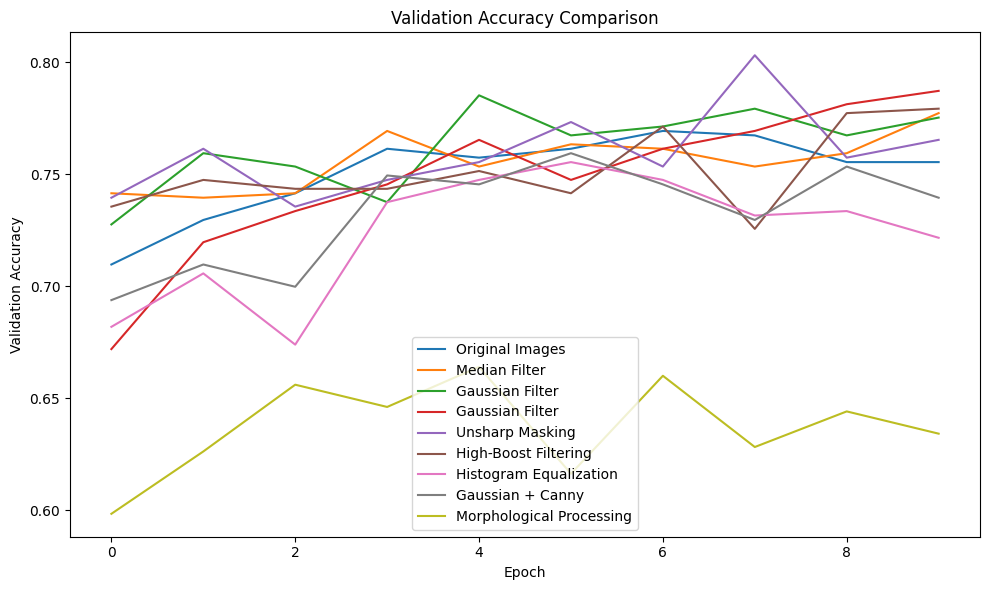

In [42]:
plt.figure(figsize=(10, 6))

for result in results:
    plt.plot(
        result["history"].history["val_accuracy"],
        label=result["method"]
    )

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## 14. Bar Chart of Final Accuracies

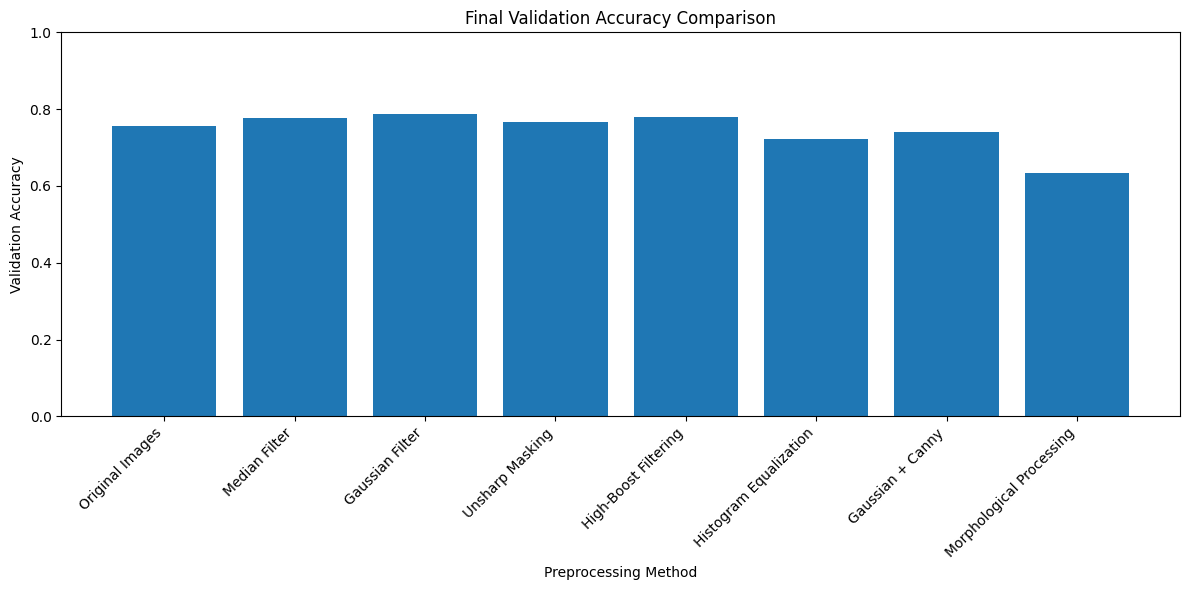

In [43]:
methods = [result["method"] for result in results]
accuracies = [result["accuracy"] for result in results]

plt.figure(figsize=(12, 6))
plt.bar(methods, accuracies)

plt.title("Final Validation Accuracy Comparison")
plt.xlabel("Preprocessing Method")
plt.ylabel("Validation Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 15. Classification Report for Best Model

In [44]:
best_model = best_result["model"]
best_val_generator = best_result["val_generator"]

y_true = best_val_generator.classes

y_pred_probs = best_model.predict(best_val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = list(best_val_generator.class_indices.keys())

print("\n========== Classification Report ==========")
print("Best Method:", best_result["method"])
print(classification_report(y_true, y_pred, target_names=class_names))

print("\n========== Confusion Matrix ==========")
cm = confusion_matrix(y_true, y_pred)
print(cm)

16/16 ━━━━━━━━━━━━━━━━━━━━ 17s 878ms/step

========== Classification Report ==========
Best Method: Gaussian Filter
              precision    recall  f1-score   support

   cardboard       0.94      0.75      0.83        80
       glass       0.74      0.81      0.77       100
       metal       0.79      0.79      0.79        82
       paper       0.79      0.92      0.85       118
     plastic       0.73      0.75      0.74        96
       trash       0.77      0.37      0.50        27

    accuracy                           0.79       503
   macro avg       0.79      0.73      0.75       503
weighted avg       0.79      0.79      0.78       503


========== Confusion Matrix ==========
[[ 60   0   2  15   2   1]
 [  0  81   9   3   7   0]
 [  0  10  65   2   5   0]
 [  4   2   1 108   2   1]
 [  0  16   3   4  72   1]
 [  0   1   2   4  10  10]]


# 16. Confusion Matrix Heatmap

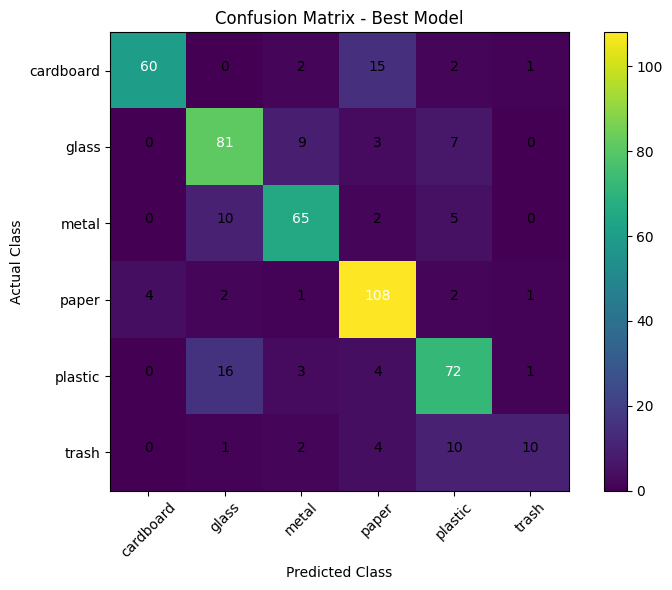

In [45]:
plt.figure(figsize=(8, 6))

plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - Best Model")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm[i, j],
            horizontalalignment="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black"
        )

plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.show()


Method: Original Images
[[ 57   1   3  16   2   1]
 [  0  91   5   1   3   0]
 [  0  15  61   1   5   0]
 [  4   2   1 104   5   2]
 [  0  37   2   1  54   2]
 [  0   2   2   2   8  13]]


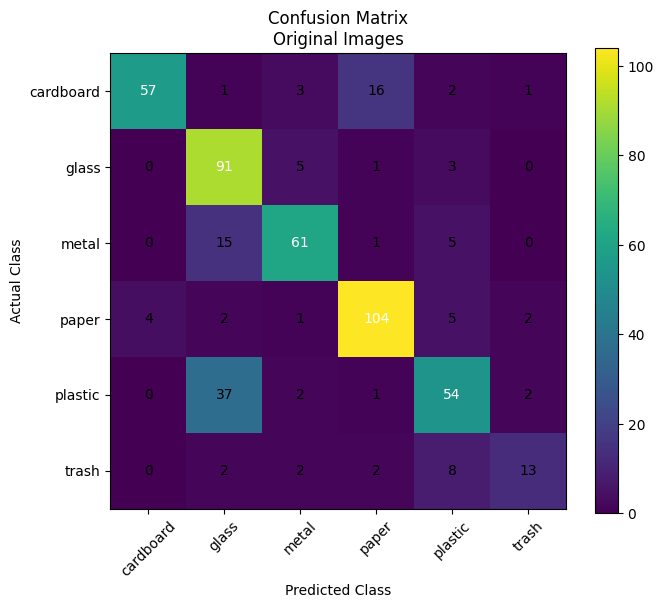


Method: Median Filter
[[ 59   0   1  18   1   1]
 [  0  87  10   2   1   0]
 [  0   6  73   2   1   0]
 [  2   1   3 109   2   1]
 [  0  25   5   7  56   3]
 [  0   1   5   6   8   7]]


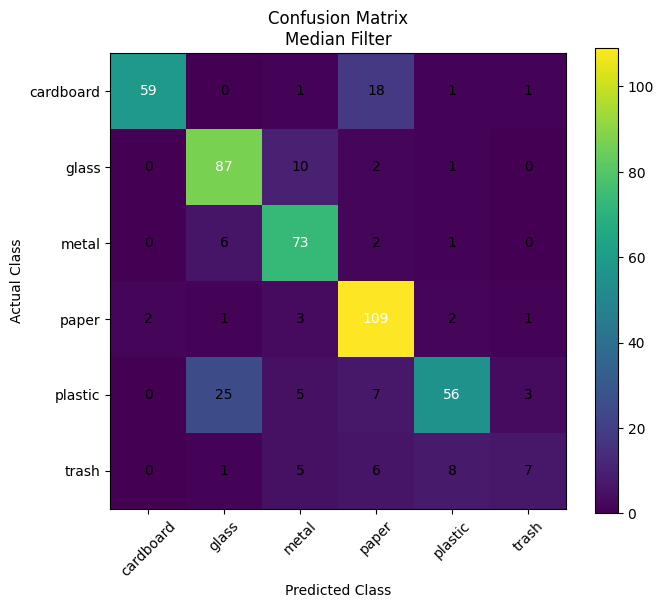


Method: Gaussian Filter
[[ 56   0   2  18   0   4]
 [  0  86   8   3   3   0]
 [  0  12  61   5   4   0]
 [  4   1   0 110   2   1]
 [  0  21   1   5  65   4]
 [  0   1   1   5   8  12]]


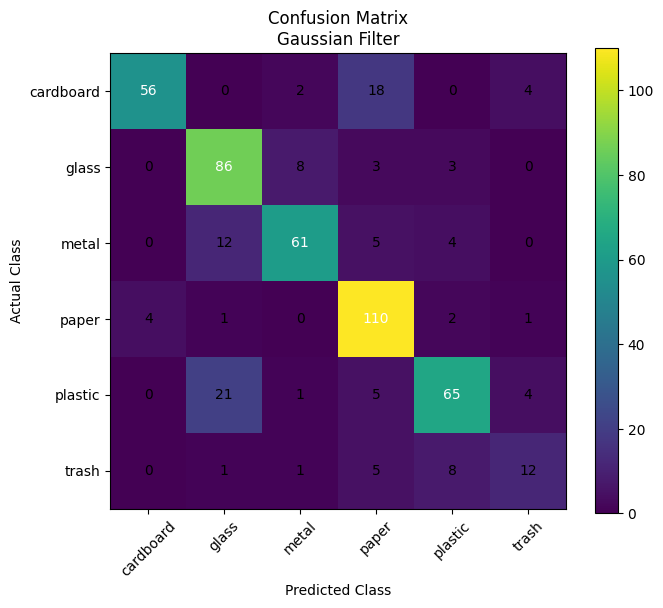


Method: Gaussian Filter
[[ 60   0   2  15   2   1]
 [  0  81   9   3   7   0]
 [  0  10  65   2   5   0]
 [  4   2   1 108   2   1]
 [  0  16   3   4  72   1]
 [  0   1   2   4  10  10]]


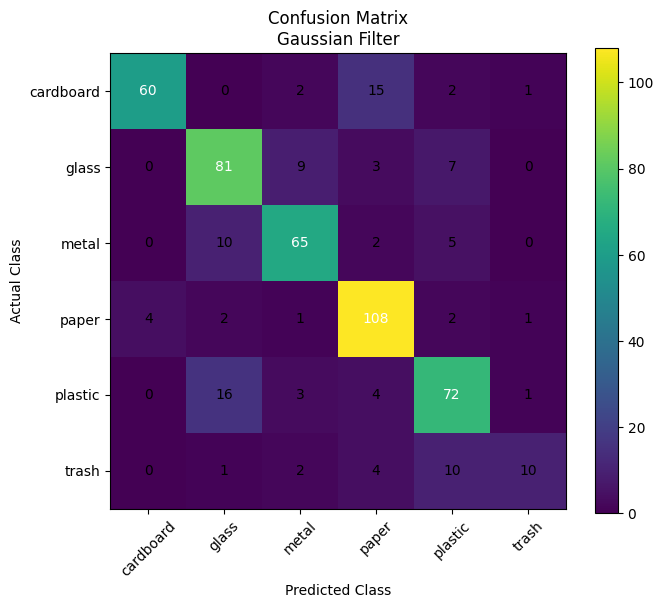


Method: Unsharp Masking
[[ 56   1   6  15   2   0]
 [  0  90   7   2   1   0]
 [  0   5  70   3   4   0]
 [  4   1   3 109   1   0]
 [  0  31   6   3  52   4]
 [  0   2   6   7   4   8]]


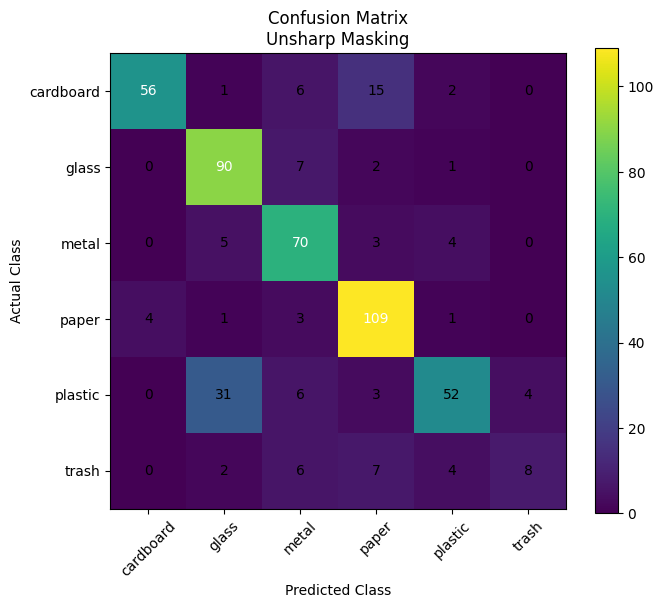


Method: High-Boost Filtering
[[ 58   0   0  18   2   2]
 [  2  85   3   3   7   0]
 [  0   9  61   2   8   2]
 [  4   2   0 108   1   3]
 [  0  17   1   2  68   8]
 [  0   2   2   3   8  12]]


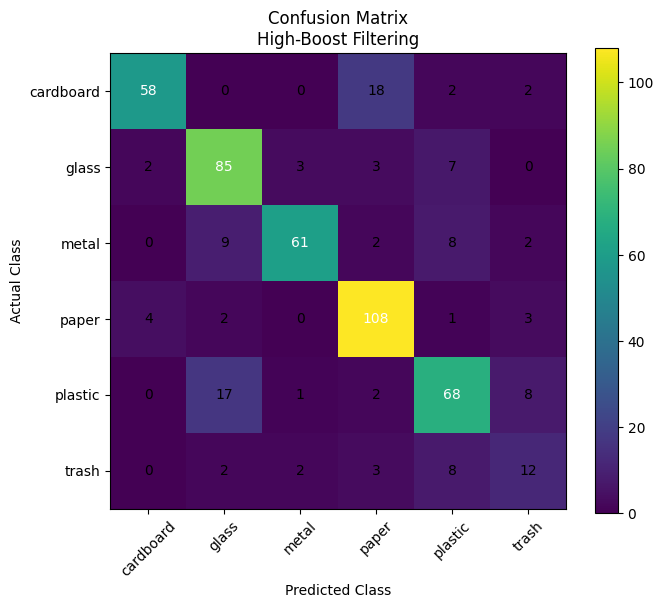


Method: Histogram Equalization
[[ 56   0   6  17   1   0]
 [  0  84  14   1   1   0]
 [  0   6  73   1   2   0]
 [  2   2   2 111   1   0]
 [  0  36  11  14  34   1]
 [  0   0   9  12   1   5]]


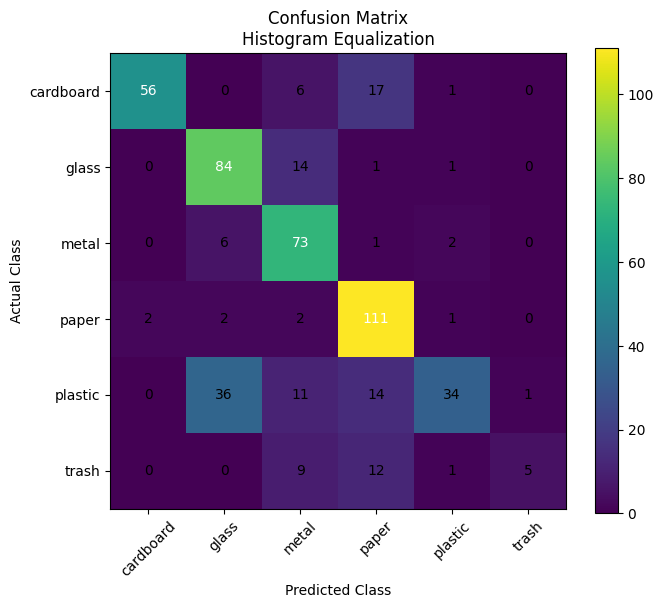


Method: Gaussian + Canny
[[ 53   1   1  20   0   5]
 [  2  73  10   5   9   1]
 [  0  10  59   5   8   0]
 [  4   1   2 107   1   3]
 [  1  14   2   6  68   5]
 [  0   2   5   4   4  12]]


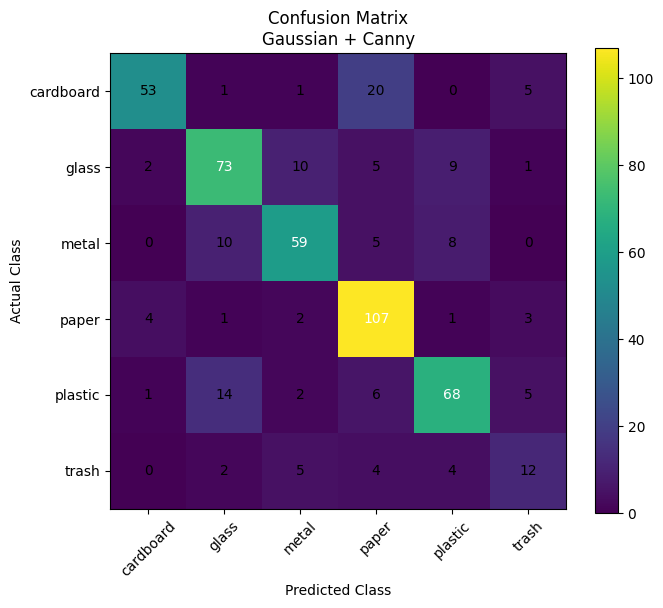


Method: Morphological Processing
[[ 49   7   4  16   2   2]
 [  0  75   9   4  12   0]
 [  0  17  51   3   7   4]
 [  3   3   3 103   1   5]
 [  1  27   5  14  35  14]
 [  0   3   2   8   8   6]]


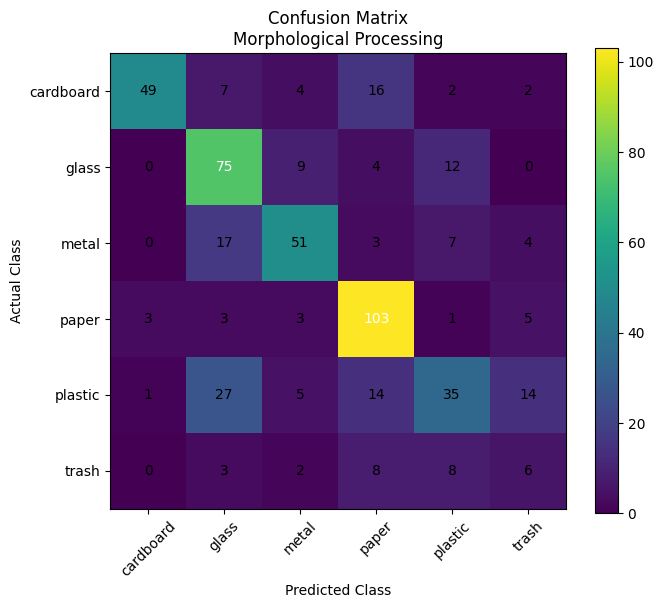

In [46]:
for result in results:

    print("\n" + "="*60)
    print("Method:", result["method"])
    print("="*60)

    model = result["model"]
    val_generator = result["val_generator"]

    # True labels
    y_true = val_generator.classes

    # Predictions
    y_pred_probs = model.predict(val_generator, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    print(cm)

    # Plot
    plt.figure(figsize=(7, 6))

    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion Matrix\n{result['method']}")
    plt.colorbar()

    tick_marks = np.arange(len(class_names))

    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black"
            )

    plt.ylabel("Actual Class")
    plt.xlabel("Predicted Class")

    plt.tight_layout()
    plt.show()

In [47]:
# ============================================================
# Training Results Figures for Each Method
# Similar to conference paper training result plots
# ============================================================

def plot_training_results(result):
    method_name = result["method"]
    history = result["history"]

    plt.figure(figsize=(10, 6))

    # Training Accuracy
    plt.subplot(2, 2, 1)
    plt.plot(history.history["accuracy"])
    plt.title("Training Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    # Validation Accuracy
    plt.subplot(2, 2, 2)
    plt.plot(history.history["val_accuracy"])
    plt.title("Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    # Training Loss
    plt.subplot(2, 2, 3)
    plt.plot(history.history["loss"])
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    # Validation Loss
    plt.subplot(2, 2, 4)
    plt.plot(history.history["val_loss"])
    plt.title("Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.suptitle(f"{method_name} Results", fontsize=16)
    plt.tight_layout()
    plt.show()

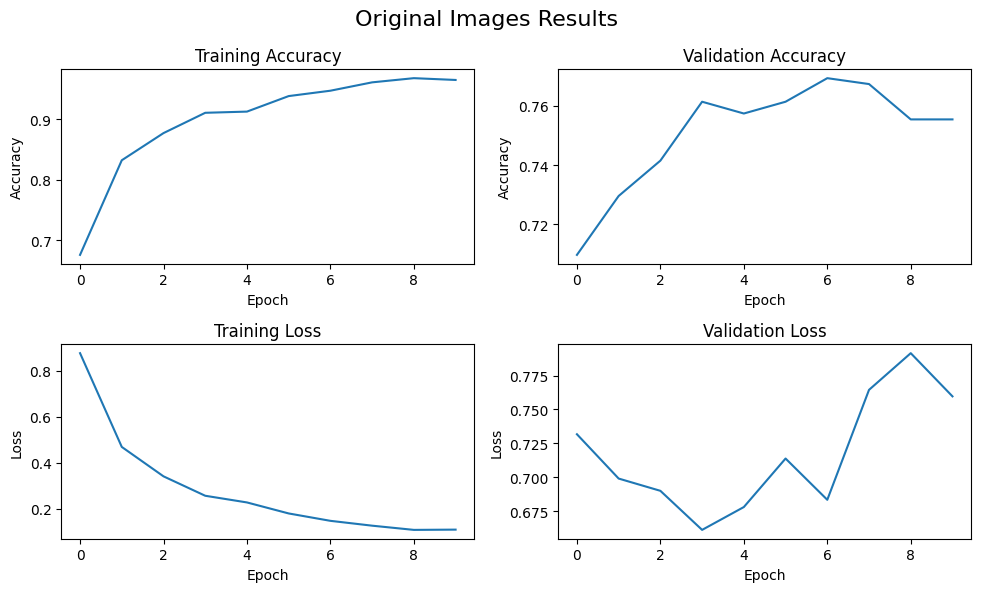

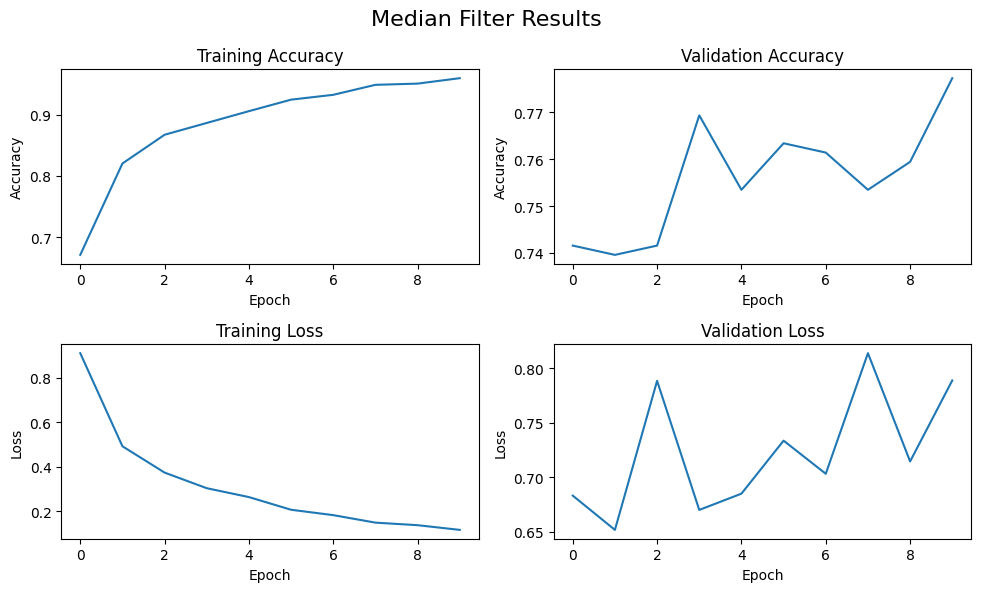

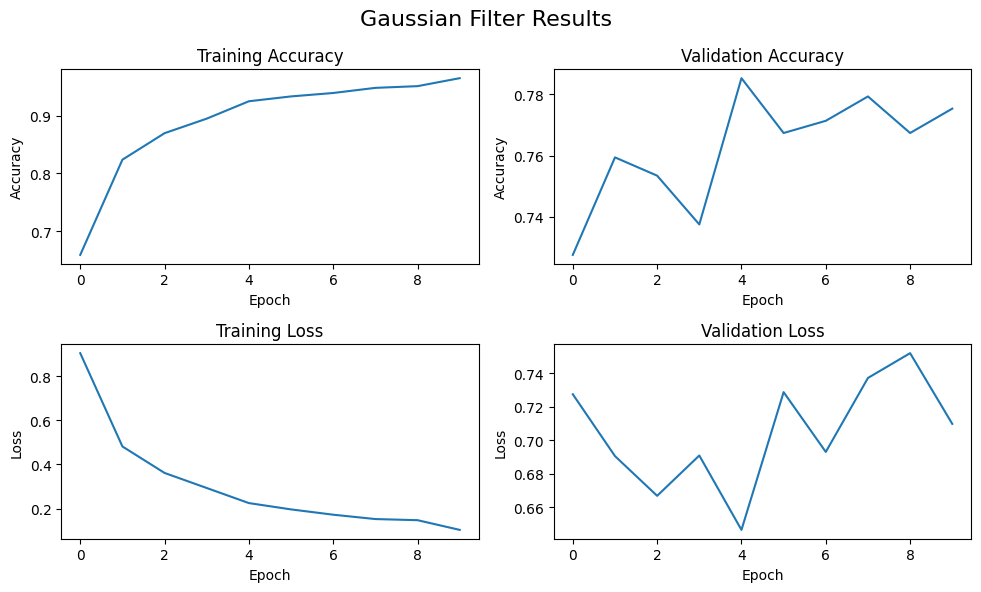

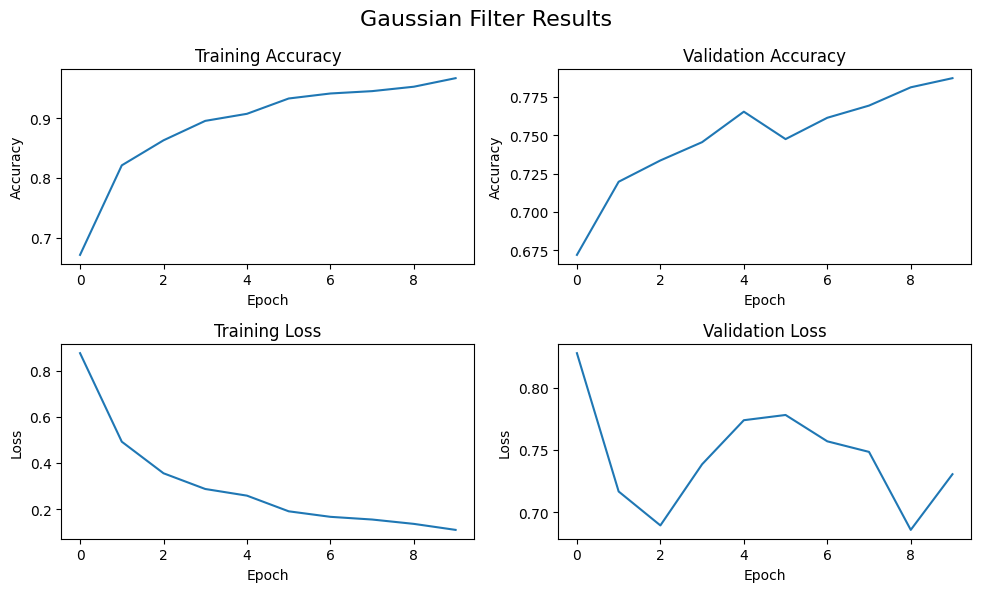

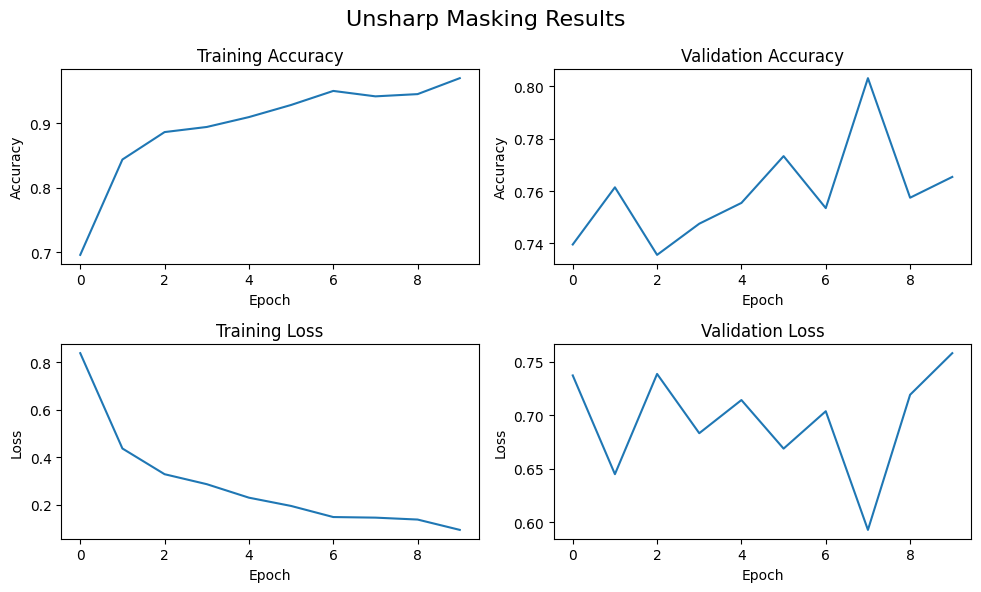

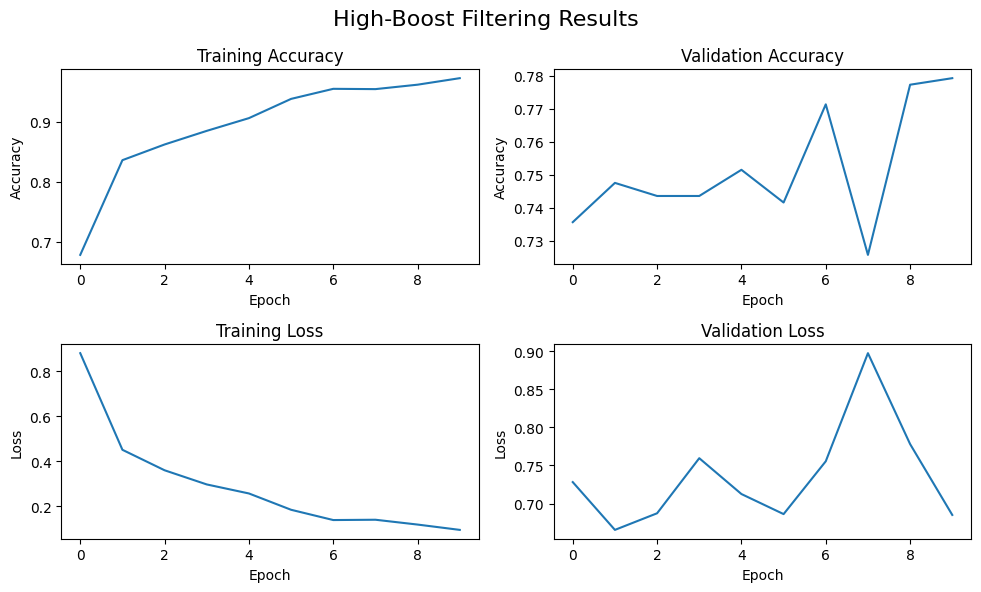

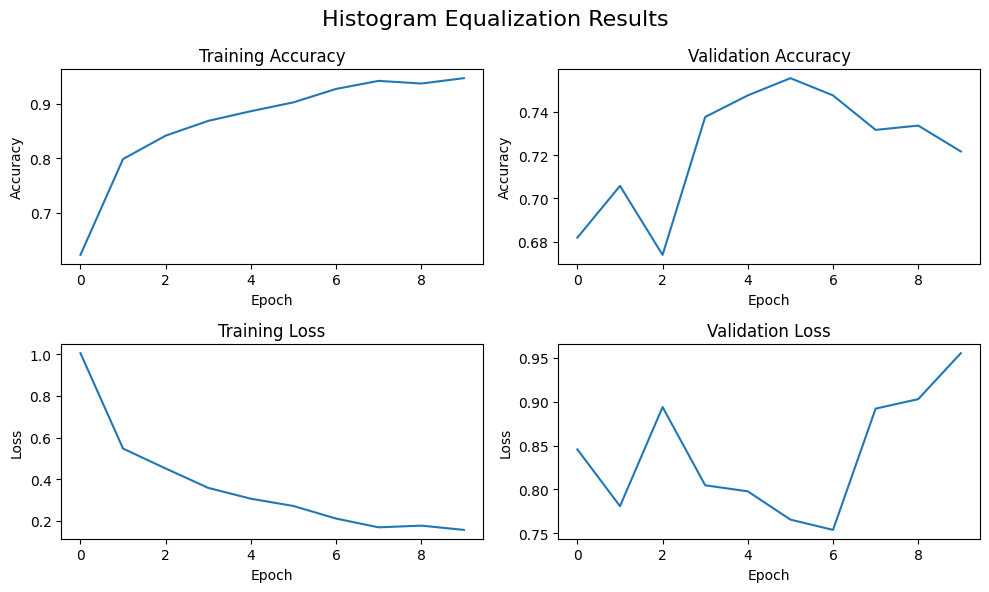

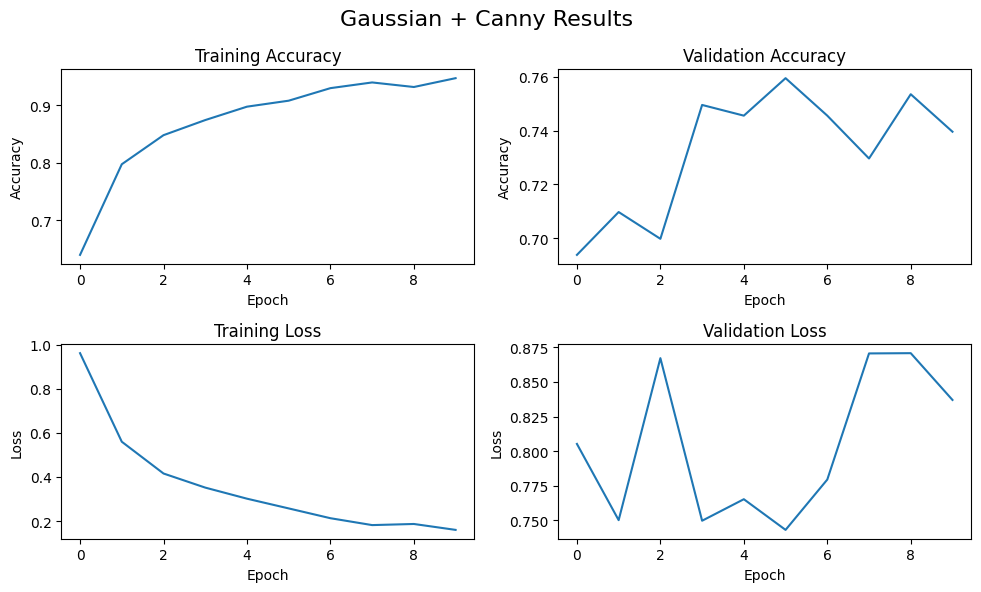

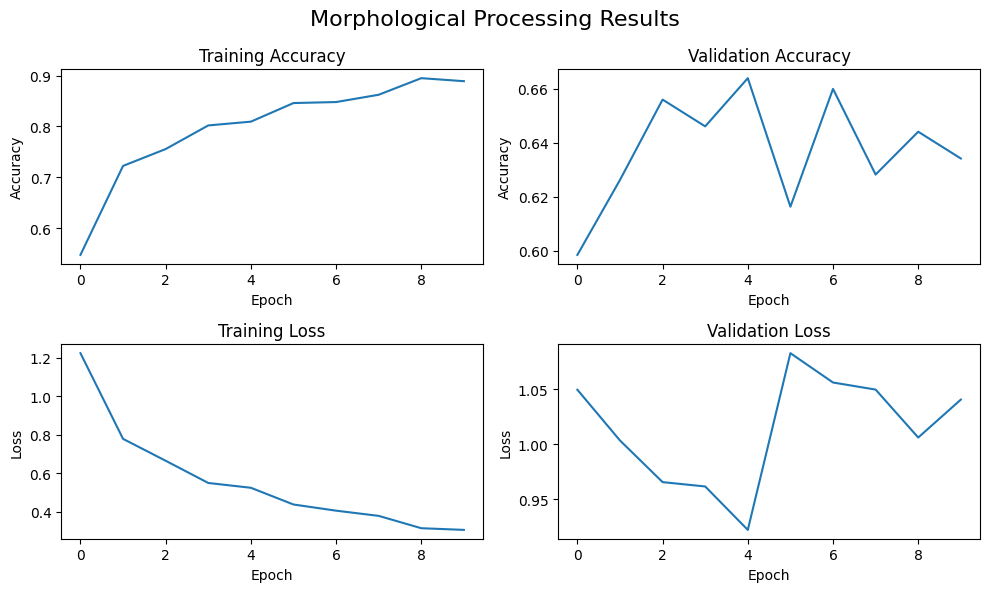

In [48]:
for result in results:
    plot_training_results(result)

In [49]:
def save_training_results(result):
    method_name = result["method"]
    history = result["history"]

    plt.figure(figsize=(10, 6))

    plt.subplot(2, 2, 1)
    plt.plot(history.history["accuracy"])
    plt.title("Training Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.subplot(2, 2, 2)
    plt.plot(history.history["val_accuracy"])
    plt.title("Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.subplot(2, 2, 3)
    plt.plot(history.history["loss"])
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.subplot(2, 2, 4)
    plt.plot(history.history["val_loss"])
    plt.title("Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.suptitle(f"{method_name} Results", fontsize=16)
    plt.tight_layout()

    filename = method_name.replace(" ", "_").replace("+", "and") + "_results.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", filename)

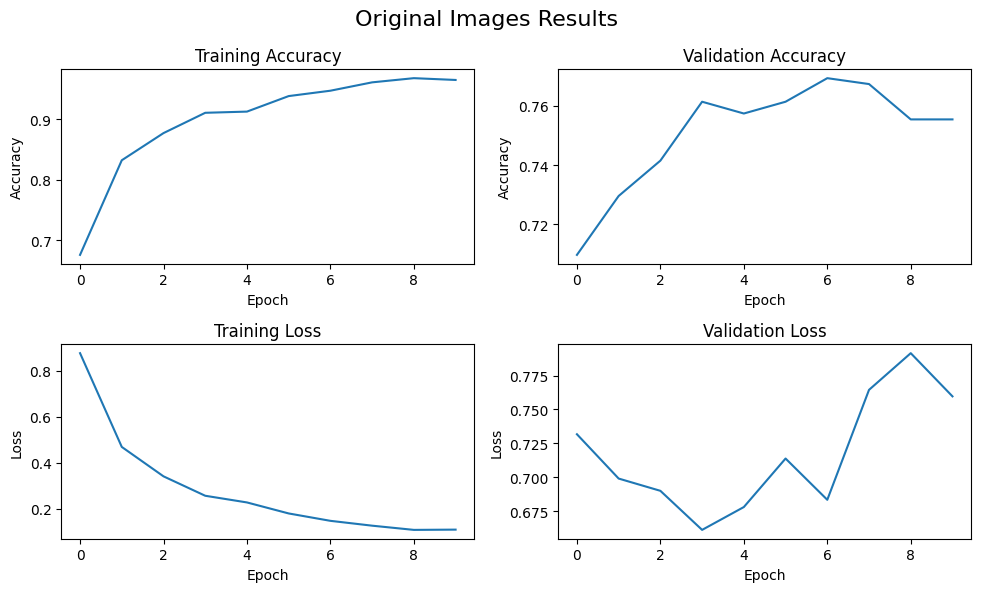

Saved: Original_Images_results.png


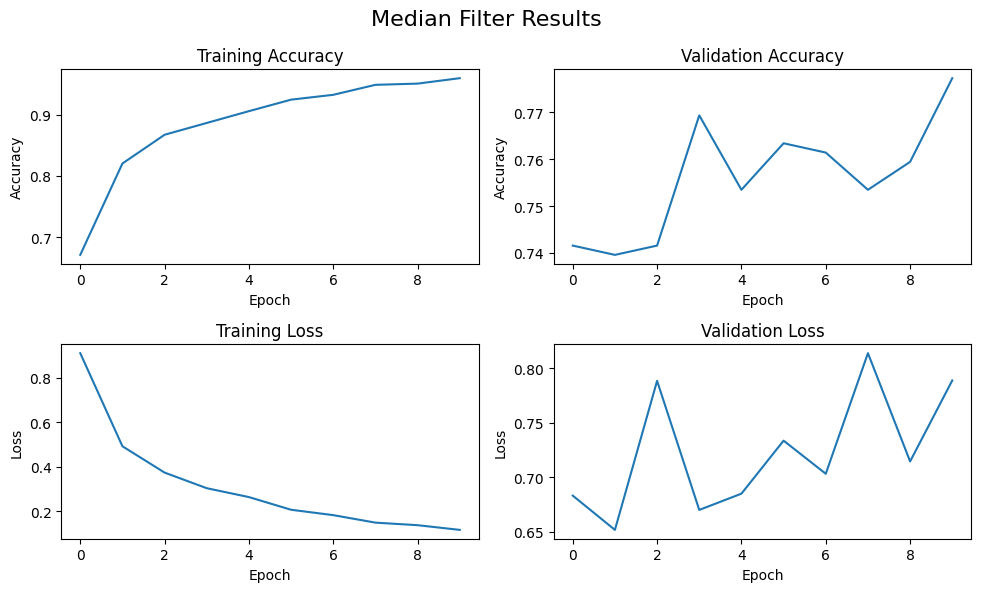

Saved: Median_Filter_results.png


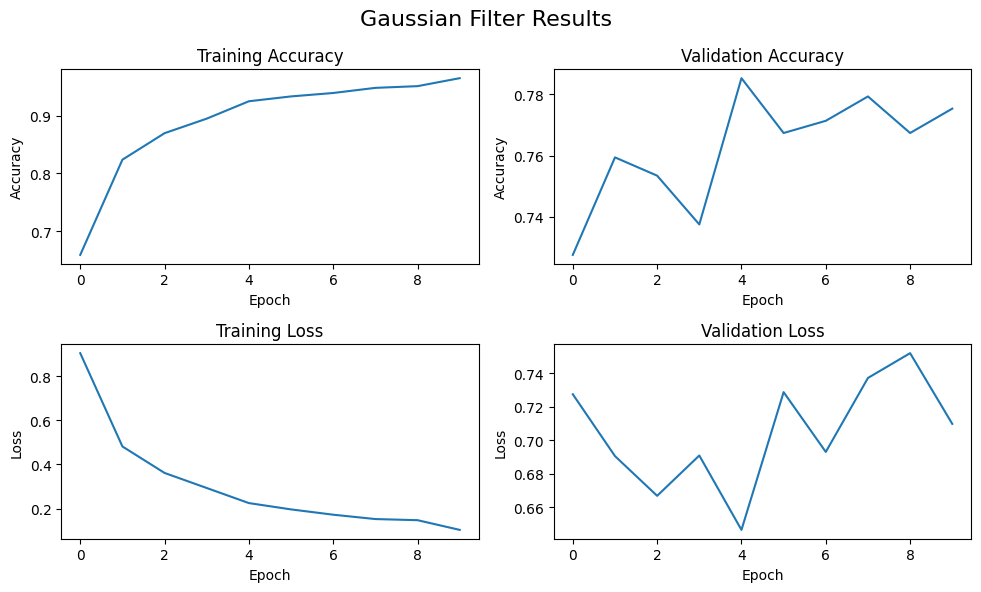

Saved: Gaussian_Filter_results.png


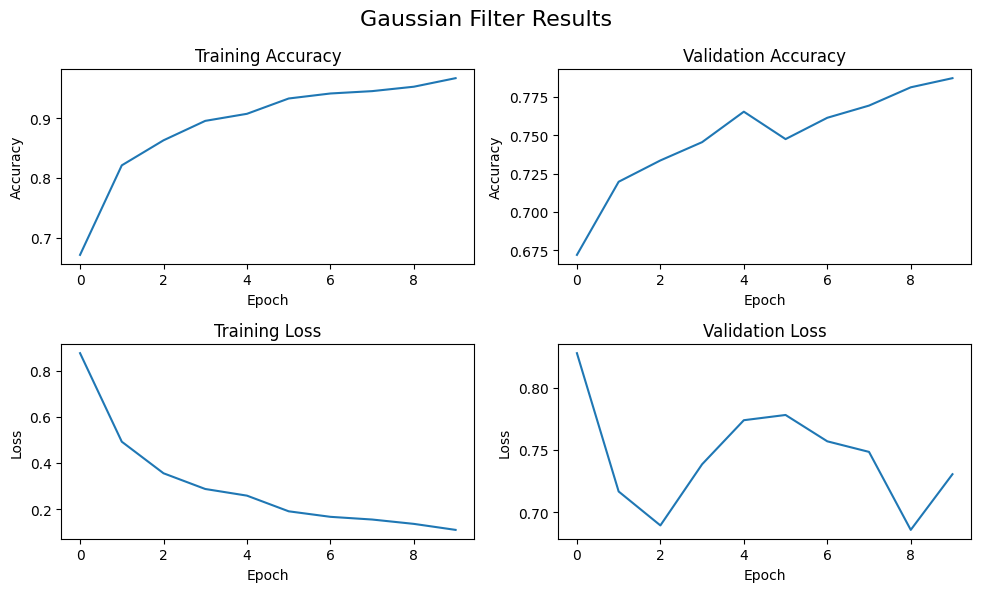

Saved: Gaussian_Filter_results.png


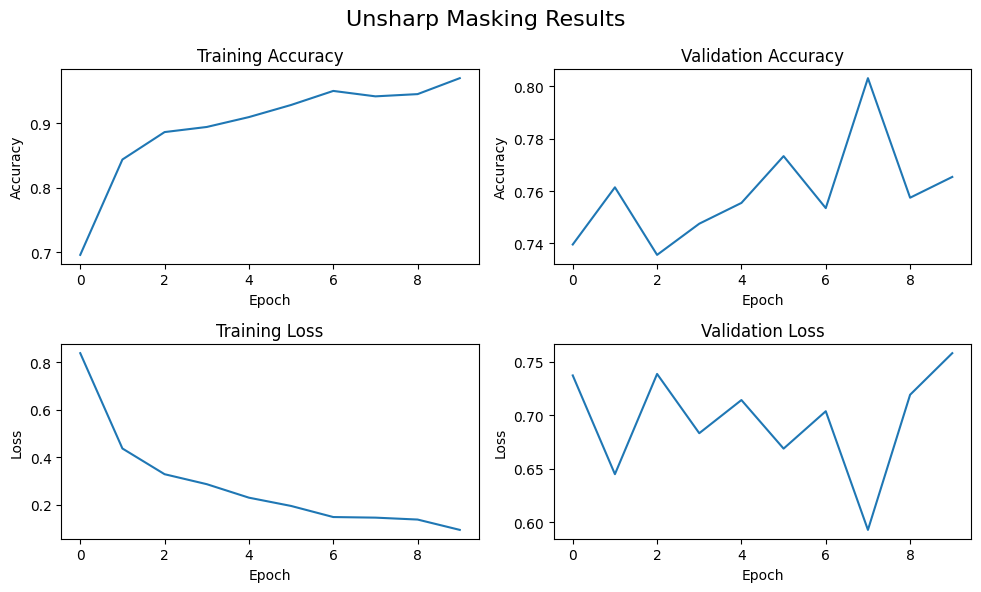

Saved: Unsharp_Masking_results.png


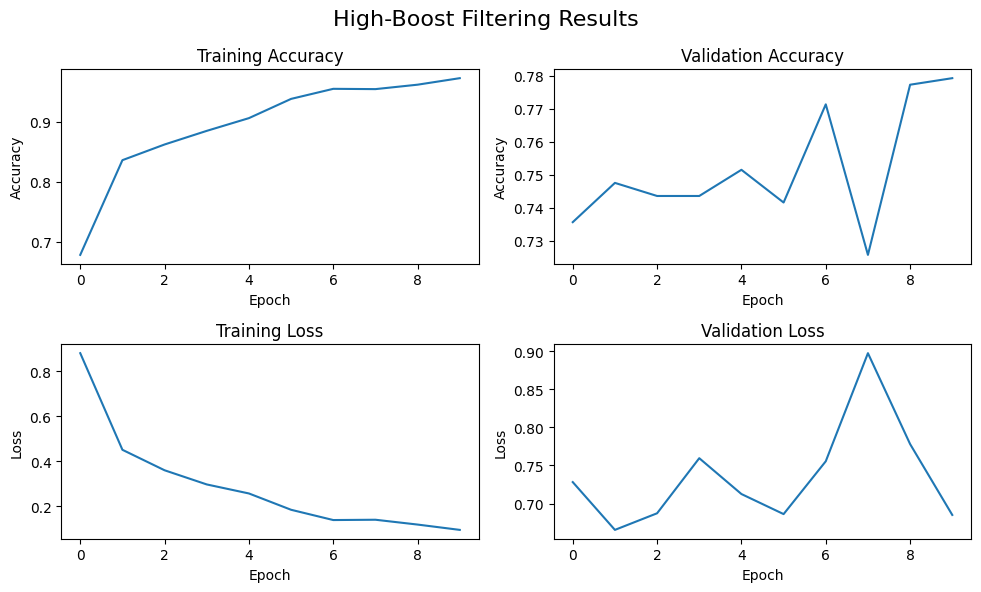

Saved: High-Boost_Filtering_results.png


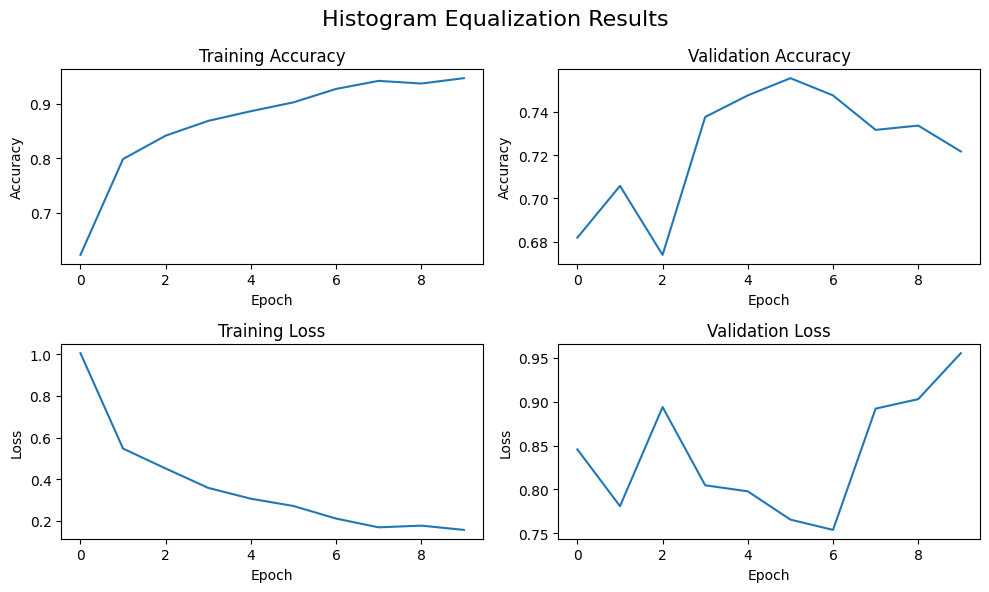

Saved: Histogram_Equalization_results.png


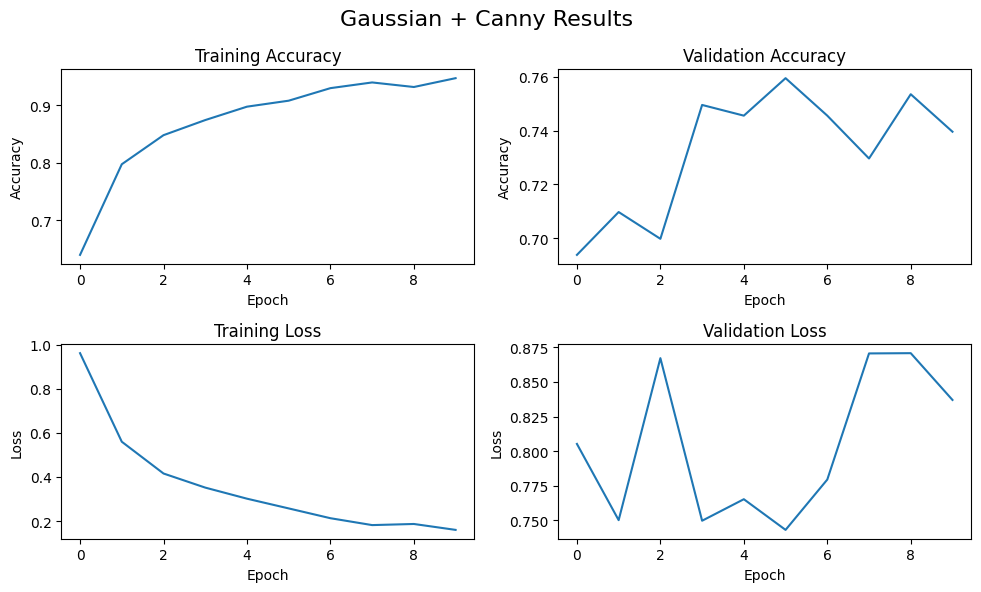

Saved: Gaussian_and_Canny_results.png


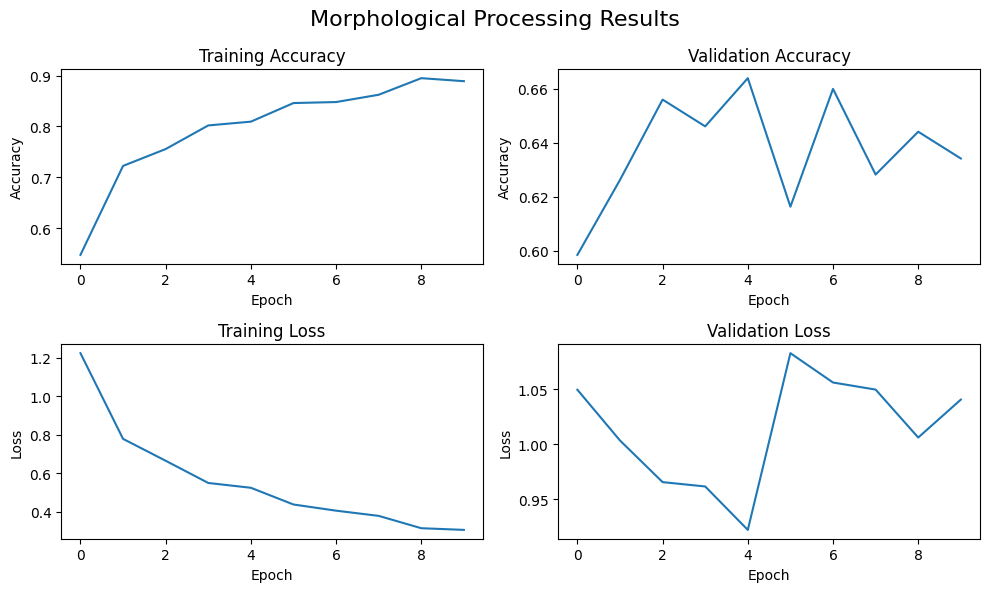

Saved: Morphological_Processing_results.png


In [50]:
for result in results:
    save_training_results(result)